### Student Information
Name:Christelia

Student ID:411855793

GitHub ID:Christy-112

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

In [1]:
### Begin Assignment Here
import pandas as pd
import numpy as np
df = pd.read_csv('newdataset/Reddit-stock-sentiment.csv')
df

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,comment,2021-06-30 4:06:06,h3iv6pq,stockstobuytoday,$MRIN Marin Software killed it today. Hope som...,Ordinary-Office9180,https://www.reddit.com/r/stockstobuytoday/comm...,1,NaN,NaN,Invest now it is going to shoot up tomorrow,0.000000,0.000000,0.0,['tomorrow'],1.0
843,comment,2025-04-11 5:01:24,mmijiuz,StockMarket,$ U.S. dollar value (crashing),lulububudu,https://i.redd.it/atvlo83gk4ue1.jpeg,2,NaN,NaN,Where can I read this?,0.000000,0.000000,0.0,[],0.0
844,post,2025-03-24 12:30:39,1jipi4v,stockstobuytoday,Analyst Recommendations,saasfin,https://www.reddit.com/r/stockstobuytoday/comm...,1,0.0,1.00,"Upgrades, Downgrades\r\n\r\n [Stock Analyst Re...",0.000000,0.000000,0.0,"['Analyst', 'Nasdaq', 'Stock', 'Upgrades', 'Do...",0.0
845,comment,2025-04-11 20:13:26,mmmely7,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,yes_ur_wrong,https://www.reddit.com/r/wallstreetbets/commen...,10,NaN,NaN,i sold my puts so i expect cheeto to declare w...,0.000000,0.000000,0.0,"['war', 'denmark', 'cheeto', 'i']",-1.0


1. Check the type of data

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   type          847 non-null    object 
 1   datetime      847 non-null    object 
 2   post_id       847 non-null    object 
 3   subreddit     847 non-null    object 
 4   title         847 non-null    object 
 5   author        847 non-null    object 
 6   url           847 non-null    object 
 7   upvotes       847 non-null    int64  
 8   downvotes     64 non-null     float64
 9   upvote_ratio  64 non-null     float64
 10  text          847 non-null    object 
 11  subjectivity  847 non-null    float64
 12  polarity      847 non-null    float64
 13  sentiment     847 non-null    float64
 14  entities      847 non-null    object 
 15  label         847 non-null    float64
dtypes: float64(6), int64(1), object(9)
memory usage: 106.0+ KB


2. Take the coloumn that will be use and change the date type to datetime. Also, extract the year incase needed later

In [3]:
df = pd.read_csv("newdataset/Reddit-stock-sentiment.csv", 
usecols = ['type', 'datetime','subreddit', 'author', 'upvotes', 'downvotes', 'upvote_ratio', 'text', 'entities', 'sentiment'])
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df['year'] = df['datetime'].dt.year
df

,type,datetime,subreddit,author,upvotes,downvotes,upvote_ratio,text,sentiment,entities,year
0,comment,2025-04-11 17:29:56,wallstreetbets,StickyTip420,0,NaN,NaN,Calls on retards,-1.0,[],2025
1,comment,2025-04-12 01:12:19,wallstreetbets,Comfortable-Dog-8437,-15,NaN,NaN,Stunt as in like why did they even make a big ...,1.0,"['Stunt', 'company', 'deal', 'place']",2025
2,comment,2025-04-10 15:09:41,StockMarket,Btankersly66,1,NaN,NaN,Seeing lots of red in the ticker.,0.0,['ticker'],2025
3,post,2023-08-30 17:12:55,stockstobuytoday,emiljenfn,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",2023
4,comment,2025-04-11 14:48:05,StockMarket,Just-Big6411,1,NaN,NaN,He didn’t say thank you.,0.0,[],2025
...,...,...,...,...,...,...,...,...,...,...,...
842,comment,2021-06-30 04:06:06,stockstobuytoday,Ordinary-Office9180,1,NaN,NaN,Invest now it is going to shoot up tomorrow,0.0,['tomorrow'],2021
843,comment,2025-04-11 05:01:24,StockMarket,lulububudu,2,NaN,NaN,Where can I read this?,0.0,[],2025
844,post,2025-03-24 12:30:39,stockstobuytoday,saasfin,1,0.0,1.00,"Upgrades, Downgrades\r\n\r\n [Stock Analyst Re...",0.0,"['Analyst', 'Nasdaq', 'Stock', 'Upgrades', 'Do...",2025
845,comment,2025-04-11 20:13:26,wallstreetbets,yes_ur_wrong,10,NaN,NaN,i sold my puts so i expect cheeto to declare w...,0.0,"['war', 'denmark', 'cheeto', 'i']",2025


3. Check duplicate and missing value

In [4]:
 df['sentiment'].unique()

array([-1.,  1.,  0.])

In [5]:
df.duplicated().sum()

0

In [6]:
df.isnull().sum()

type              0
datetime          0
subreddit         0
author            0
upvotes           0
downvotes       783
upvote_ratio    783
text              0
sentiment         0
entities          0
year              0
dtype: int64

In [7]:
import helpers.data_mining_helpers as dmh

df.isnull().apply(lambda x: dmh.check_missing_values(x),axis=1)

0      (The amoung of missing records is: , 2)
1      (The amoung of missing records is: , 2)
2      (The amoung of missing records is: , 2)
3      (The amoung of missing records is: , 0)
4      (The amoung of missing records is: , 2)
                        ...                   
842    (The amoung of missing records is: , 2)
843    (The amoung of missing records is: , 2)
844    (The amoung of missing records is: , 0)
845    (The amoung of missing records is: , 2)
846    (The amoung of missing records is: , 2)
Length: 847, dtype: object

4. Drop unnecessary coloumns

In [8]:
df = df.dropna(axis=1)
df

,type,datetime,subreddit,author,upvotes,text,sentiment,entities,year
0,comment,2025-04-11 17:29:56,wallstreetbets,StickyTip420,0,Calls on retards,-1.0,[],2025
1,comment,2025-04-12 01:12:19,wallstreetbets,Comfortable-Dog-8437,-15,Stunt as in like why did they even make a big ...,1.0,"['Stunt', 'company', 'deal', 'place']",2025
2,comment,2025-04-10 15:09:41,StockMarket,Btankersly66,1,Seeing lots of red in the ticker.,0.0,['ticker'],2025
3,post,2023-08-30 17:12:55,stockstobuytoday,emiljenfn,30,Vision Marine Technologies Inc. is rewriting t...,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",2023
4,comment,2025-04-11 14:48:05,StockMarket,Just-Big6411,1,He didn’t say thank you.,0.0,[],2025
...,...,...,...,...,...,...,...,...,...
842,comment,2021-06-30 04:06:06,stockstobuytoday,Ordinary-Office9180,1,Invest now it is going to shoot up tomorrow,0.0,['tomorrow'],2021
843,comment,2025-04-11 05:01:24,StockMarket,lulububudu,2,Where can I read this?,0.0,[],2025
844,post,2025-03-24 12:30:39,stockstobuytoday,saasfin,1,"Upgrades, Downgrades\r\n\r\n [Stock Analyst Re...",0.0,"['Analyst', 'Nasdaq', 'Stock', 'Upgrades', 'Do...",2025
845,comment,2025-04-11 20:13:26,wallstreetbets,yes_ur_wrong,10,i sold my puts so i expect cheeto to declare w...,0.0,"['war', 'denmark', 'cheeto', 'i']",2025


In [9]:
 df['text'].isnull().sum()

0

5. Distribution between types

In [10]:
df['type'].unique()

# Count occurrences of each subreddit
type_counts = df['type'].value_counts()
print(type_counts)

type
comment    783
post        64
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11736\4174633507.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette="magma")


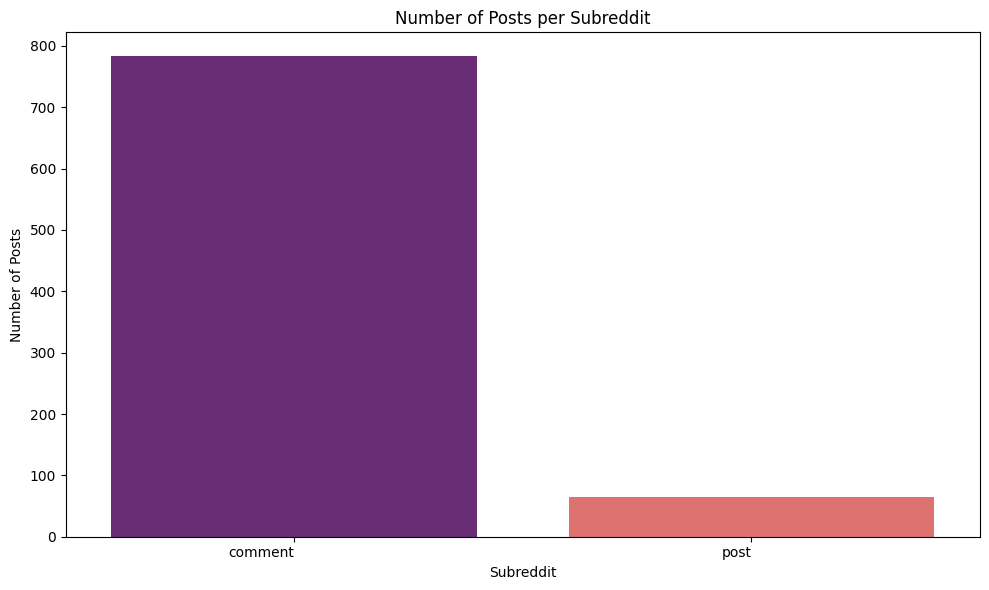

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

type_counts = type_counts.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=type_counts.index, y=type_counts.values, palette="magma")
plt.title('Number of Posts per Subreddit')
plt.xlabel('Subreddit')
plt.ylabel('Number of Posts')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

6. Distribution between subreddits

In [12]:
# Count occurrences of each subreddit
subreddit_counts = df['subreddit'].value_counts()
print(subreddit_counts)

subreddit
stocks              274
StockMarket         250
stockstobuytoday    174
wallstreetbets      149
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11736\4143369582.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subreddit_counts.index, y=subreddit_counts.values, palette="magma")


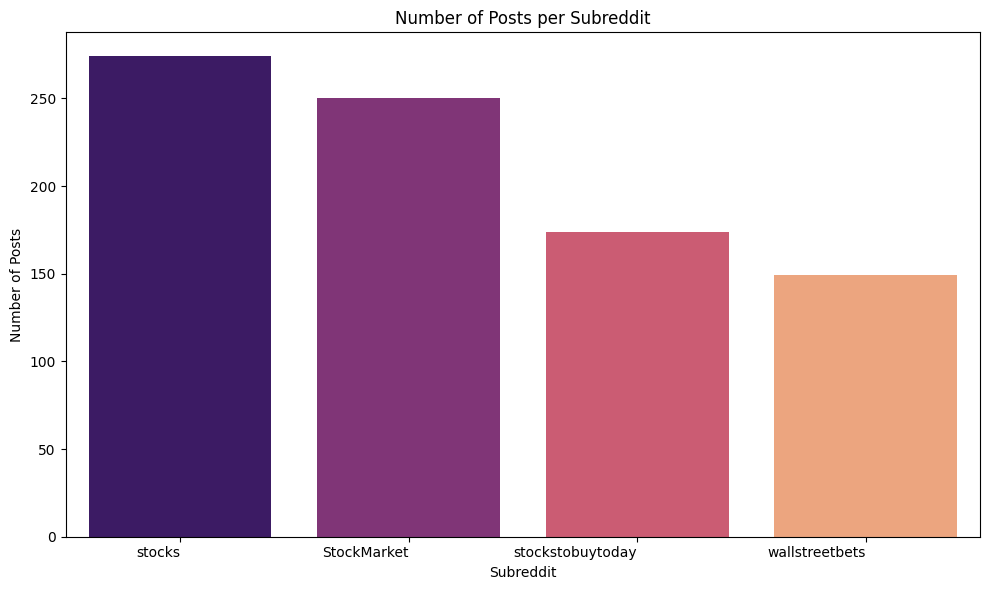

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

subreddit_counts = subreddit_counts.sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=subreddit_counts.index, y=subreddit_counts.values, palette="magma")
plt.title('Number of Posts per Subreddit')
plt.xlabel('Subreddit')
plt.ylabel('Number of Posts')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

7. Take sample from full data to make a comparison

In [14]:
df_sample = df.sample(n=400)
print(df_sample.subreddit.value_counts())


subreddit
stocks              134
StockMarket         117
stockstobuytoday     80
wallstreetbets       69
Name: count, dtype: int64


<Figure size 900x400 with 0 Axes>

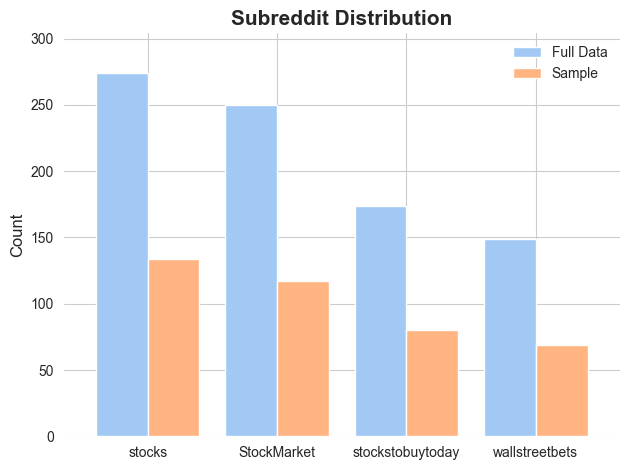

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get counts
subreddit_counts = df['subreddit'].value_counts()
df_sample_counts = df_sample['subreddit'].value_counts()

# Create DataFrame (pandas aligns index automatically)
df_plot = pd.DataFrame({
    "Full Data": subreddit_counts,
    "Sample": df_sample_counts
}).fillna(0)

df_plot = df_plot.sort_values(by="Full Data", ascending=False)


sns.set_style("whitegrid")  
plt.figure(figsize=(9, 4))

ax = df_plot.plot(
    kind='bar',
    color=sns.color_palette("pastel", 2),  
    width=0.8
)

# Styling
plt.title("Subreddit Distribution", fontsize=15, weight='bold')
plt.xlabel("")
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, subreddit_counts.max() + 30)
plt.legend(frameon=False)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

8. Import nltk for text prepocessing

In [16]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize

# Download required NLTK data (run once)
nltk.download('punkt')        # for sent_tokenize & word_tokenize
nltk.download('stopwords')    # for stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
def tokenize_text_subreddit(text):
    stop_words = set(stopwords.words('english'))
    tokens = []
    for sentence in nltk.sent_tokenize(text):
        for word in nltk.word_tokenize(sentence):
            if word.isalpha() and word.lower() not in stop_words:
                tokens.append(word.lower())  # ← ensure lowercase!
    return tokens

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

# Use your custom tokenizer
count_vect = CountVectorizer(
    tokenizer=tokenize_text_subreddit,
    lowercase=False,        # ← not needed (you handle case in tokenizer)
    stop_words=None,        # ← not needed (you handle stop words)
    token_pattern=None      # ← ignored when tokenizer is provided
)

In [19]:
# Use your custom tokenizer
count_vect = CountVectorizer(
    tokenizer=tokenize_text_subreddit,
    lowercase=False,        # ← not needed (you handle case in tokenizer)
    stop_words=None,        # ← not needed (you handle stop words)
    token_pattern=None      # ← ignored when tokenizer is provided
)

In [20]:
analyze = count_vect.build_analyzer()
analyze(df.text[0])

['calls', 'retards']

C:\Users\ASUS\Documents\DM2025-Lab2-Exercise\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


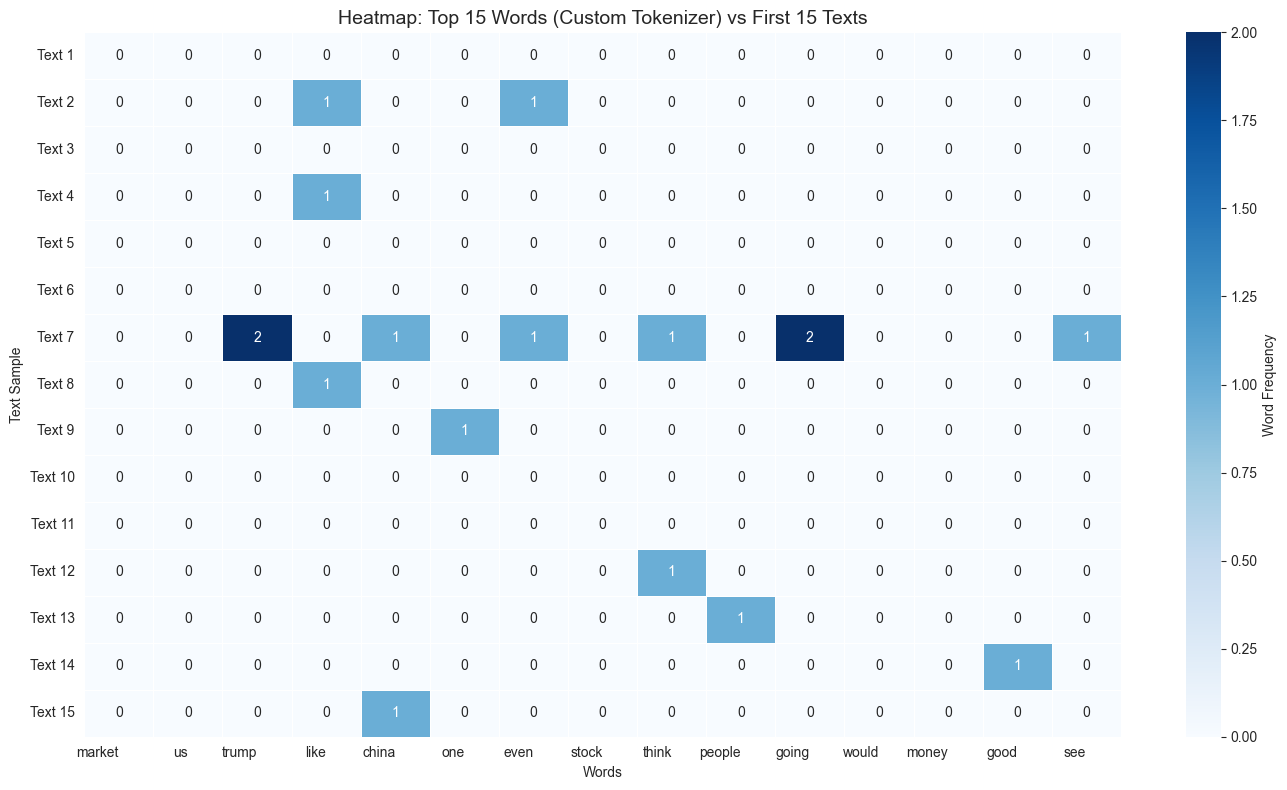

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

count_vect = CountVectorizer(
    tokenizer=tokenize_text_subreddit,
    lowercase=False,   # handled inside your function
    stop_words=None,   # handled inside your function
    token_pattern=None # ignored when tokenizer is provided
)

X_full = count_vect.fit_transform(df['text'].astype(str))

# Get total counts for each word
word_counts = np.array(X_full.sum(axis=0)).flatten()
feature_names = count_vect.get_feature_names_out()

# Get top 15 most frequent words (from entire dataset)
top_15_indices = word_counts.argsort()[-15:][::-1]
top_15_words = feature_names[top_15_indices]

# Now, restrict vectorizer to ONLY these top 15 words
count_vect_top15 = CountVectorizer(
    tokenizer=tokenize_text_subreddit,
    lowercase=False,
    stop_words=None,
    vocabulary=top_15_words  # ← forces only these words
)

# Take first 15 texts
first_15_texts = df['text'].iloc[:15].astype(str).tolist()

# Transform them using the restricted vocabulary
X_first15 = count_vect_top15.fit_transform(first_15_texts).toarray()

# Create DataFrame for heatmap
heatmap_data = pd.DataFrame(
    X_first15,
    index=[f'Text {i+1}' for i in range(len(first_15_texts))],
    columns=top_15_words
)

# Optional: Sort columns by total frequency (descending)
heatmap_data = heatmap_data[top_15_words]  # already in order, but safe

# Plot the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    annot=True,           # show counts in cells
    fmt='d',              # integer format
    cmap='Blues',
    cbar_kws={'label': 'Word Frequency'},
    linewidths=0.5        # optional: add lines between cells
)
plt.title('Heatmap: Top 15 Words (Custom Tokenizer) vs First 15 Texts', fontsize=14)
plt.xlabel('Words')
plt.ylabel('Text Sample')
plt.xticks(rotation=0, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
import numpy as np
import pandas as pd
import plotly.express as px


from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer()
X = count_vect.fit_transform(df['text'].astype(str))  # X is sparse matrix

# Get term frequencies from X (NOT from df!)
term_frequencies = np.asarray(X.sum(axis=0)).flatten()  # shape: (n_features,)

#  Get first N terms from the VOCABULARY
first_n = 100
terms = count_vect.get_feature_names_out()[:first_n]
frequencies = term_frequencies[:first_n]  # now same length as terms!

#  Create DataFrame
df_terms = pd.DataFrame({
    'Term': terms,
    'Frequency': frequencies
})


fig = px.bar(
    df_terms,
    x='Term',
    y='Frequency',
    title=f'Frequency of First {first_n} Terms in Vocabulary',
    labels={'Term': 'Term', 'Frequency': 'Frequency'},
    color='Frequency',
    color_continuous_scale='Viridis'
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=600,
    width=1200,
    showlegend=False,
    margin=dict(l=50, r=50, t=80, b=100)
)

fig.update_traces(
    hovertemplate="<b>%{x}</b><br>Frequency: %{y}<extra></extra>"
)

fig.show()

In [23]:
# Assuming your DataFrame is `df` with column 'text'
X = count_vect.fit_transform(df['text'].astype(str))

# Get word counts
word_counts = X.sum(axis=0).A1  # .A1 converts matrix to 1D array
feature_names = count_vect.get_feature_names_out()

# Step 1: Get indices of top 80 MOST FREQUENT words
top_n = 80
top_indices_by_freq = word_counts.argsort()[-top_n:][::-1]

# Step 2: Extract those words and counts
top_words = feature_names[top_indices_by_freq]
top_counts = word_counts[top_indices_by_freq]

# Step 3: Sort them ALPHABETICALLY (by word)
sorted_order = np.argsort(top_words)  # indices that would sort the words
top_words_alpha = top_words[sorted_order]
top_counts_alpha = top_counts[sorted_order]

# Optional: Print
for word, count in zip(top_words_alpha, top_counts_alpha):
    print(f"{word}: {count}")


about: 72
all: 97
an: 47
and: 488
any: 45
are: 155
as: 115
at: 92
be: 134
been: 37
but: 108
by: 58
can: 85
china: 72
do: 53
even: 52
for: 214
from: 63
get: 37
going: 50
good: 46
has: 76
have: 97
he: 132
him: 36
his: 51
how: 55
if: 119
in: 286
is: 402
it: 350
just: 95
like: 83
make: 36
market: 111
money: 46
more: 67
my: 89
no: 61
not: 107
now: 62
of: 311
on: 171
one: 54
only: 39
or: 81
other: 36
out: 45
people: 51
re: 57
see: 43
so: 103
some: 52
stock: 51
tariffs: 39
than: 41
that: 238
the: 920
their: 72
them: 52
there: 62
they: 150
think: 52
this: 213
time: 36
to: 566
trump: 92
up: 55
us: 96
was: 94
we: 81
what: 88
when: 42
who: 41
why: 38
will: 127
with: 126
would: 45
you: 195
your: 48


In [24]:
# Plot
import plotly.express as px

fig = px.bar(
    x=top_words_alpha,
    y=top_counts_alpha,
    labels={'x': 'Word', 'y': 'Frequency'},
    title='Top 80 Most Frequent Words (Alphabetical Order)',
    color=top_counts_alpha,
    color_continuous_scale='magma',
    text=top_counts_alpha
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=600,
    width=900
)

fig.show()

In [25]:
# Assuming your DataFrame is `df` with column 'text'
X = count_vect.fit_transform(df['text'].astype(str))

# Get word counts
word_counts = X.sum(axis=0).A1  # .A1 converts matrix to 1D array
feature_names = count_vect.get_feature_names_out()

# Get top 80
top_indices = word_counts.argsort()[-80:][::-1]
top_words = feature_names[top_indices]
top_counts = word_counts[top_indices]

# Print or plot
for word, count in zip(top_words, top_counts):
    print(f"{word}: {count}")

the: 920
to: 566
and: 488
is: 402
it: 350
of: 311
in: 286
that: 238
for: 214
this: 213
you: 195
on: 171
are: 155
they: 150
be: 134
he: 132
will: 127
with: 126
if: 119
as: 115
market: 111
but: 108
not: 107
so: 103
have: 97
all: 97
us: 96
just: 95
was: 94
at: 92
trump: 92
my: 89
what: 88
can: 85
like: 83
we: 81
or: 81
has: 76
their: 72
about: 72
china: 72
more: 67
from: 63
now: 62
there: 62
no: 61
by: 58
re: 57
up: 55
how: 55
one: 54
do: 53
some: 52
even: 52
think: 52
them: 52
his: 51
people: 51
stock: 51
going: 50
your: 48
an: 47
good: 46
money: 46
out: 45
would: 45
any: 45
see: 43
when: 42
who: 41
than: 41
only: 39
tariffs: 39
why: 38
been: 37
get: 37
time: 36
make: 36
him: 36
other: 36


In [26]:
import plotly.express as px

# Create interactive bar chart
fig = px.bar(
    x=top_words,
    y=top_counts,
    labels={'x': 'Word', 'y': 'Frequency'},
    title='Top 80 Words',
    color=top_counts,
    color_continuous_scale='magma',
    text=top_counts  # Show counts on bars
)

# Improve layout
fig.update_layout(
    xaxis_tickangle=-45,  # Rotate word labels
    height=600,
    width=800
)

# Show interactive plot
fig.show()

In [27]:
import numpy as np
import pandas as pd
import plotly.express as px

# Assuming you already have:
# count_vect = CountVectorizer(...)
# X = count_vect.fit_transform(df['text'].astype(str))

# Get raw word counts from sparse matrix
word_counts = X.sum(axis=0).A1  # shape: (n_features,)
feature_names = count_vect.get_feature_names_out()

# Get top 80 terms by frequency
top_n = 80
top_indices = word_counts.argsort()[-top_n:][::-1]

# Extract top words and their raw counts
top_words = feature_names[top_indices]
top_counts = word_counts[top_indices]

# Apply safe log transform: log(1 + count)
top_counts_log = np.log1p(top_counts)

# Create DataFrame for Plotly
df_terms = pd.DataFrame({
    'Term': top_words,
    'Log Frequency': top_counts_log  # ← clearly labeled!
})

# Create interactive bar chart
fig = px.bar(
    df_terms,
    x='Term',
    y='Log Frequency',
    title=f'Top {top_n} Words (Log Frequency)',
    labels={'Term': 'Word', 'Log Frequency': 'Log(1 + Frequency)'},
    color='Log Frequency',
    color_continuous_scale='magma',
    text=top_counts  # show RAW counts on bars (more intuitive)
)

# Improve layout
fig.update_layout(
    xaxis_tickangle=-45,
    height=600,
    width=1000,
    showlegend=False
)

# Optional: format hover and text
fig.update_traces(
    hovertemplate="<b>%{x}</b><br>Raw Count: %{text}<br>Log Freq: %{y:.2f}<extra></extra>",
    texttemplate="%{text}",
    textposition="outside"
)

fig.show()

### New data visualizations

1. Pie Chart about Sentiment Distribution

In [28]:
# Count occurrences of each sentiment
sentiment_counts = df['sentiment'].value_counts()

print(sentiment_counts)

sentiment
 0.0    331
 1.0    319
-1.0    197
Name: count, dtype: int64


In [29]:
import plotly.graph_objects as go

# Prepare data
sentiment_counts = df['sentiment'].value_counts().reindex([-1.0, 0.0, 1.0], fill_value=0)
labels = ['Negative (-1.0)', 'Neutral (0.0)', 'Positive (1.0)']
values = sentiment_counts.values
colors = ['#e74c3c', '#bdc3c7', '#2ecc71']

# Create donut chart
fig = go.Figure(data=[go.Pie(
    labels=labels,
    values=values,
    hole=0.5,  # makes it a donut
    marker_colors=colors,
    textinfo='percent+label',
    hovertemplate="<b>%{label}</b><br>Count: %{value}<br>Percentage: %{percent}<extra></extra>",
    textfont_size=14
)])

# Update layout
fig.update_layout(
    title={
        'text': "Sentiment Distribution (Interactive Donut)",
        'x': 0.5,
        'xanchor': 'center',
        'font_size': 18
    },
    showlegend=True,
    width=700,
    height=600
)

fig.show()

2. Line Chart to see activity over the time

In [30]:
df['year'].unique()
df['year'].value_counts()

year
2025    690
2021     99
2022     22
2024     22
2023     14
Name: count, dtype: int64

In [31]:
# Count and pivot in one step using unstack()
yearly_pivot = df.groupby(['year', 'subreddit']).size().unstack(fill_value=0)

# Optional: Ensure year is integer (to avoid 2021.0 on plots)
yearly_pivot.index = yearly_pivot.index.astype(int)

print(yearly_pivot)

subreddit  StockMarket  stocks  stockstobuytoday  wallstreetbets
year                                                            
2021                 0      41                58               0
2022                 0       0                22               0
2023                 0       0                14               0
2024                 0       0                22               0
2025               250     233                58             149


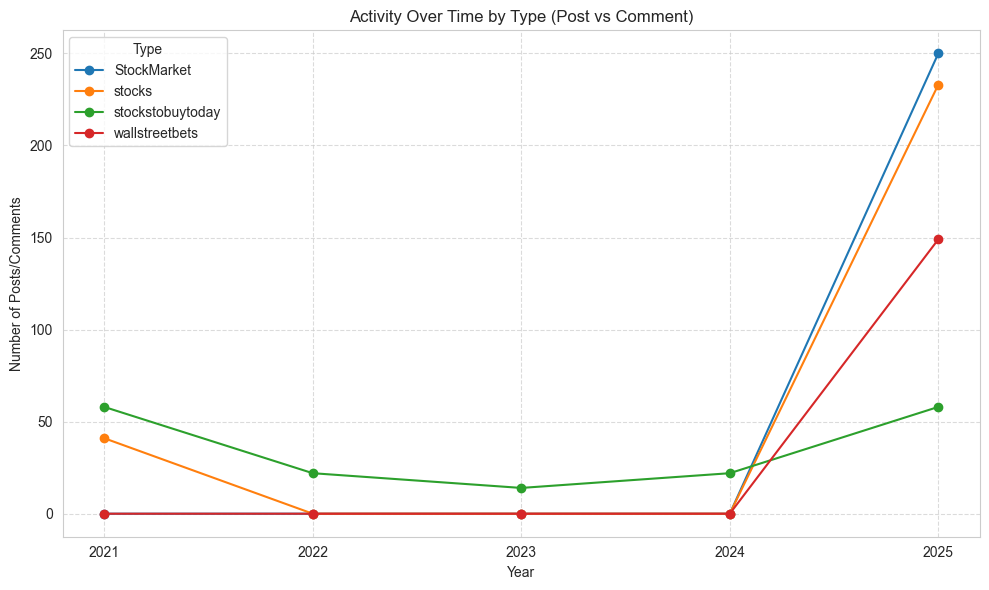

In [32]:
import matplotlib.pyplot as plt

ax = yearly_pivot.plot(kind='line', marker='o', figsize=(10, 6))
ax.set_xticks(yearly_pivot.index)  # Only show existing years
ax.set_xticklabels(yearly_pivot.index.astype(int))  # Ensure they're integers
plt.title('Activity Over Time by Type (Post vs Comment)')
plt.xlabel('Year')
plt.ylabel('Number of Posts/Comments')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Type')
plt.tight_layout()
plt.show()

3. Boxplot to visualize the distribution of upvotes across different subreddits

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11736\3205581371.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




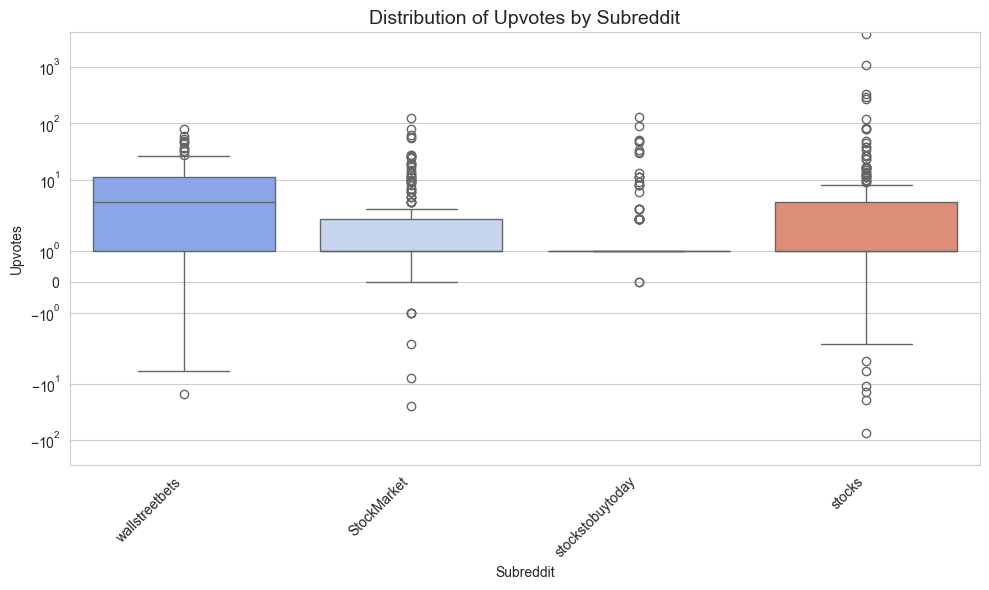

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='subreddit',
    y='upvotes',
    palette='coolwarm'  # or 'Set2', 'viridis', etc.
)

plt.title('Distribution of Upvotes by Subreddit', fontsize=14)
plt.xlabel('Subreddit')
plt.ylabel('Upvotes')
plt.xticks(rotation=45, ha='right')
plt.yscale('symlog')  # handles negative and large positive values
plt.tight_layout()
plt.show()

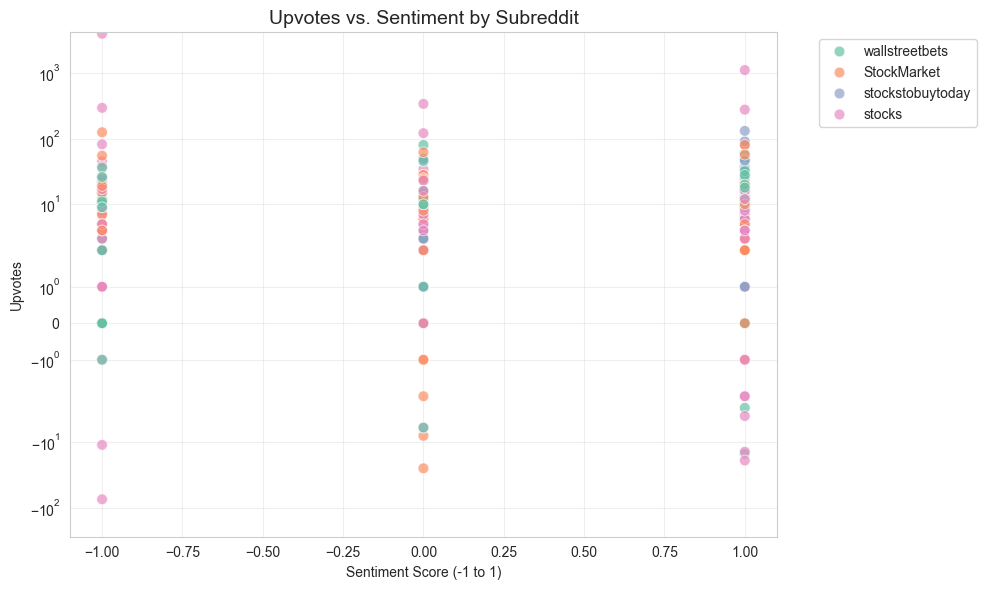

In [34]:
plt.figure(figsize=(10, 6))

# Create scatter plot
sns.scatterplot(
    data=df,
    x='sentiment',
    y='upvotes',
    hue='subreddit',          # Color by subreddit
    palette='Set2',           # Good for categorical coloring
    alpha=0.7,                # Slight transparency for overlap
    s=60                      # Marker size
)

# Customize
plt.title('Upvotes vs. Sentiment by Subreddit', fontsize=14)
plt.xlabel('Sentiment Score (-1 to 1)')
plt.ylabel('Upvotes')
plt.grid(True, alpha=0.3)
plt.yscale('symlog')  # Keep symlog to handle negative upvotes and large positives
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside
plt.tight_layout()
plt.show()

# Phase 2

In [34]:
### Begin Assignment Here
df['subreddit'].value_counts()

subreddit
stocks              274
StockMarket         250
stockstobuytoday    174
wallstreetbets      149
Name: count, dtype: int64

In [35]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

#Create separate DataFrames for each subreddit
subreddits = df['subreddit'].unique()  # Get unique subreddit labels
subreddit_dfs = {}  # Dictionary to store DataFrames for each subreddit

for subreddit in subreddits:
    # Filter the original DataFrame by subreddit
    #print(subreddit)
    subreddit_dfs[subreddit] = df[df['subreddit'] == subreddit].copy()
    #print(subreddit_dfs[subreddit])

#Function to create term-document frequency DataFrame for each subreddit
def create_term_document_df(df):
    count_vect = CountVectorizer()  # Initialize the CountVectorizer
    df_counts = count_vect.fit_transform(df['text'])  # Transform the text data into word counts
    #fit: It reads all the text in your df['text'] column and builds a complete dictionary (or "vocabulary") of every unique word it finds.
    # transform: It then creates a big matrix where:
    # Each row is one of your text documents.
    # Each column is a unique word from the vocabulary.
    # The value in any cell (row, column) is the count of how many times that word (column) appeared in that document (row).

#Get the unique words (vocabulary) from the vectorizer
    words = count_vect.get_feature_names_out()
    #fetches the vocabulary (the list of all unique words) that CountVectorizer learned from your text.

#Create a DataFrame where rows are documents and columns are words
    term_document_df = pd.DataFrame(df_counts.toarray(), columns=words)
    # This is the line that actually sets the headers.It takes the word list from Step 1 and uses it as the columns for your new DataFrame.
    return term_document_df

#Create term-document frequency DataFrames for each subreddit
filt_term_document_dfs = {}  # Dictionary to store term-document DataFrames for each subreddit

for subreddit in subreddits:
    filt_term_document_dfs[subreddit] = create_term_document_df(subreddit_dfs[subreddit])

In [36]:
for subreddit in subreddits: 
    print(f"Filtered Term-Document Frequency DataFrame for subreddit {subreddit}:")
    print(filt_term_document_dfs[subreddit])

Filtered Term-Document Frequency DataFrame for subreddit wallstreetbets:
     10  100  1000  10k  12  17th  186  18630  1934  1981  ...  xi  year  \
0     0    0     0    0   0     0    0      0     0     0  ...   0     0   
1     0    0     0    0   0     0    0      0     0     0  ...   0     0   
2     0    0     0    0   0     0    0      0     0     0  ...   0     0   
3     0    0     0    0   0     0    0      0     0     0  ...   0     0   
4     0    0     0    0   0     0    0      0     0     0  ...   0     0   
..   ..  ...   ...  ...  ..   ...  ...    ...   ...   ...  ...  ..   ...   
144   0    0     0    0   0     0    0      0     0     0  ...   0     0   
145   0    0     0    0   0     0    0      0     0     0  ...   0     0   
146   0    0     0    0   0     0    0      0     0     0  ...   0     0   
147   0    0     0    0   0     0    0      0     0     0  ...   0     0   
148   0    0     0    0   0     0    0      0     0     0  ...   0     0   

     years  ye

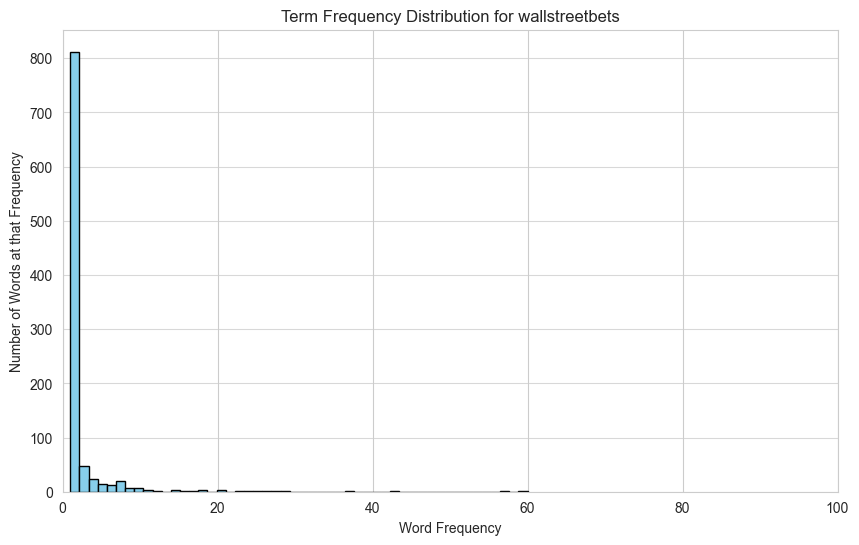

In [37]:
# 1. Directly specify the subreddit you want to analyze
subreddit_name = 'wallstreetbets'

# 2. Get the term-document matrix for 'wallstreetbets' from the dictionary
tdm_df = filt_term_document_dfs[subreddit_name]

# 3. Sum over all documents to get total frequency for each word
word_counts = tdm_df.sum(axis=0).to_numpy()
 
# 4. Visualize the frequency distribution
plt.figure(figsize=(10, 6))
plt.hist(word_counts, bins=50, color='skyblue', edgecolor='black')
plt.title(f'Term Frequency Distribution for {subreddit_name}')
plt.xlabel('Word Frequency')
plt.ylabel('Number of Words at that Frequency')
plt.xlim(0, 100) # Adjusted for better visibility
plt.grid(axis='y', alpha=0.75)
plt.show()

### look first at the words that we will be filtering based on the set percentage threshold in each subreddit

In [38]:
# Loop through each subreddit and its corresponding term-document matrix
for subreddit_name, tdm_df in filt_term_document_dfs.items():

    # Skip if the DataFrame for the subreddit is empty
    if tdm_df.empty:
        print(f"--- Subreddit: {subreddit_name} ---")
        print("No terms found to analyze.\n")
        continue

    # Get the names of the terms (the column headers)
    term_names = tdm_df.columns
    # Sum over all documents to get the total frequency for each word
    word_counts = tdm_df.sum(axis=0).to_numpy()

    # Sort the term frequencies in descending order
    sorted_indices = np.argsort(word_counts)[::-1]

    total_terms = len(word_counts)
    # Calculate the number of terms that make up the top 5%
    top_5_percent_count = int(0.05 * total_terms)

    # Ensure we show at least one term if there are any words at all
    if top_5_percent_count == 0 and total_terms > 0:
        top_5_percent_count = 1

    # Get the indices of the top 5% most frequent terms
    top_5_percent_indices = sorted_indices[:top_5_percent_count]

    # Get the actual word names using the top indices
    filtered_words = [term_names[i] for i in top_5_percent_indices]

    # --- Print the results for the current subreddit ---
    print(f"--- Subreddit: {subreddit_name} ---")
    print(f"Total unique terms: {total_terms}")
    print(f"Number of terms in top 5%: {len(filtered_words)}")
    print(f"Top 5% most frequent terms: {filtered_words}\n")

--- Subreddit: wallstreetbets ---
Total unique terms: 972
Number of terms in top 5%: 48
Top 5% most frequent terms: ['to', 'the', 'it', 'and', 'in', 'is', 'you', 'for', 'they', 'this', 'of', 'my', 'that', 'on', 't5_2th52', 'emote', 'img', 'so', 'like', 'but', 'can', 'just', 'at', 'are', 'have', 'over', 'all', 'was', 'target', 'will', 'be', 'now', 'not', 'we', 'about', 'there', 'what', 'puts', 'no', 'good', 'up', 'make', 'she', 're', 'time', 'with', 'still', 'market']

--- Subreddit: StockMarket ---
Total unique terms: 1593
Number of terms in top 5%: 79
Top 5% most frequent terms: ['the', 'to', 'and', 'is', 'it', 'of', 'in', 'that', 'he', 'this', 'they', 'for', 'you', 'trump', 'are', 'so', 'just', 'be', 'not', 'his', 'was', 'will', 'china', 'us', 'all', 'if', 'we', 'as', 'have', 'with', 'or', 'what', 'about', 'but', 'has', 'their', 'on', 'can', 'at', 'him', 're', 'how', 'do', 'no', 'one', 'more', 'them', 'doesn', 'my', 'going', 'doing', 'who', 'up', 'would', 'make', 'out', 'when', 'like

In [39]:
for subreddit_name, tdm_df in filt_term_document_dfs.items():

    if tdm_df.empty:
        print(f"--- Subreddit: {subreddit_name} ---")
        print("No terms found to analyze.\n")
        continue

    term_names = tdm_df.columns
    word_counts = tdm_df.sum(axis=0).to_numpy()

    # --- CHANGE 1: Sort in ASCENDING order (least frequent first) by removing [::-1] ---
    sorted_indices = np.argsort(word_counts)

    total_terms = len(word_counts)
    
    # --- CHANGE 2: Calculate 1% instead of 5% ---
    bottom_1_percent_count = int(0.01 * total_terms)

    # Ensure we show at least one term if there are any words at all
    if bottom_1_percent_count == 0 and total_terms > 0:
        bottom_1_percent_count = 1

    # Get the indices of the bottom 1% least frequent terms
    bottom_1_percent_indices = sorted_indices[:bottom_1_percent_count]

    # Get the actual word names using the bottom indices
    filtered_words = [term_names[i] for i in bottom_1_percent_indices]

    # --- Update the print statements for clarity ---
    print(f"--- Subreddit: {subreddit_name} ---")
    print(f"Total unique terms: {total_terms}")
    print(f"Number of terms in bottom 1%: {len(filtered_words)}")
    print(f"Bottom 1% least frequent terms: {filtered_words}\n")

--- Subreddit: wallstreetbets ---
Total unique terms: 972
Number of terms in bottom 1%: 9
Bottom 1% least frequent terms: ['31224', '31225', '350', '1981', '1m', '20', '200k', '2012', '2021']

--- Subreddit: StockMarket ---
Total unique terms: 1593
Number of terms in bottom 1%: 15
Bottom 1% least frequent terms: ['1947', '1953', '1961', 'wow', 'wrote', 'ww2', 'yea', 'yes', '250', '28', '2s', '36', '3d', '401k', '404']

--- Subreddit: stockstobuytoday ---
Total unique terms: 1618
Number of terms in bottom 1%: 16
Bottom 1% least frequent terms: ['worth', 'plg', '153', '15m', '16', '1728', '17th', '18', '1992', 'plug', '200', '2017', '2021', '20211209', 'pocket', 'zone']

--- Subreddit: stocks ---
Total unique terms: 2346
Number of terms in bottom 1%: 23
Bottom 1% least frequent terms: ['50k', '50x', '52', '60', '65', '70', '77', '22rate', '235', '2045', '31f', '17', '160', '18', '1870', '10000', 'standstill', '456', '4d', 'yoyo', 'xeqt', 'ya', 'yea']



### Filter the bottom 1% and top 5% words based on their sum across all documents

In [40]:
def filter_top_bottom_words_by_sum(term_document_df, top_percent=0.05, bottom_percent=0.01):
    """
    Identifies and prints the most and least frequent words, then returns a
    DataFrame with those words removed.
    """
    if term_document_df.empty:
        return pd.DataFrame()
        
    # Calculate the sum of each word across all documents
    word_sums = term_document_df.sum(axis=0)
    
    # Sort the words by their total sum (ascending)
    sorted_words = word_sums.sort_values()
    
    # Calculate the number of words to select
    total_words = len(sorted_words)
    top_n = int(top_percent * total_words)
    bottom_n = int(bottom_percent * total_words)
    
    # Get the actual Series for the top and bottom words
    bottom_words_series = sorted_words.head(bottom_n)
    top_words_series = sorted_words.tail(top_n)

    # --- Print in the exact format you requested ---
    print(f'Bottom {bottom_percent*100:.1f}% words:')
    print(bottom_words_series)
    print(f'\nTop {top_percent*100:.1f}% words:')
    print(top_words_series)
    
    # Get the index (the words themselves) of the Series to remove
    words_to_remove = pd.concat([bottom_words_series, top_words_series]).index
    
    # Return the DataFrame without the filtered words
    return term_document_df.drop(columns=words_to_remove)


# MODIFIED loop to produce the final output
# This dictionary will store the DataFrames after the words have been removed
filtered_tdm_dfs = {}

# Loop through each subreddit
for subreddit_name, tdm_df in filt_term_document_dfs.items():
    # Print the main header for each subreddit
    print(f"\nFor subreddit {subreddit_name} we filter the following words:")
    
    # Call the function, which now handles the detailed printing inside it
    filtered_tdm_dfs[subreddit_name] = filter_top_bottom_words_by_sum(tdm_df)
    
    new_word_count = filtered_tdm_dfs[subreddit_name].shape[1]
    print(f"Number of words after filtering: {new_word_count}")

    # Access the DataFrame using the string key 'wallstreetbets'
filtered_tdm_dfs['wallstreetbets']


For subreddit wallstreetbets we filter the following words:
Bottom 1.0% words:
31224    1
31225    1
350      1
1981     1
1m       1
20       1
200k     1
2012     1
2021     1
dtype: int64

Top 5.0% words:
market       8
still        8
with         8
time         8
re           8
she          8
make         8
up           9
good         9
no           9
puts         9
what         9
there        9
about        9
we          10
not         10
now         10
be          10
will        10
target      10
was         11
all         11
over        11
have        12
are         12
at          14
just        15
can         15
but         15
like        16
so          17
img         18
emote       18
t5_2th52    18
on          20
that        21
my          21
of          23
this        24
they        25
for         26
you         28
is          29
in          29
and         37
it          43
the         57
to          60
dtype: int64
Number of words after filtering: 915

For subreddit StockM

,10,100,1000,10k,12,17th,186,18630,1934,208,...,wutang,xi,year,years,yesterday,yet,yippee,your,yourself,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
145,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
146,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
147,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [41]:
import pandas as pd
from PAMI.extras.convert.DF2DB import DF2DB

# Loop through the dictionary of FILTERED term-document DataFrames
for subreddit_name in filtered_tdm_dfs:
    
    # Create the conversion object using the filtered DataFrame
    obj = DF2DB(filtered_tdm_dfs[subreddit_name])
    
    # Convert and save, overwriting the old file
    obj.convert2TransactionalDatabase(f'td_freq_db_{subreddit_name}.csv', '>=', 1)
    
    print(f"Successfully updated '{subreddit_name}' transactional database with filtered data.")

Successfully updated 'wallstreetbets' transactional database with filtered data.
Successfully updated 'StockMarket' transactional database with filtered data.
Successfully updated 'stockstobuytoday' transactional database with filtered data.
Successfully updated 'stocks' transactional database with filtered data.


In [42]:
import builtins

_orig_open = open

def safe_open(*args, **kwargs):
    if len(args) > 0 and isinstance(args[0], str) and args[0].endswith('.csv'):
        kwargs['encoding'] = 'latin-1'   # Force Latin-1
        kwargs['errors'] = 'ignore'      # Ignore bad characters
    return _orig_open(*args, **kwargs)


builtins.open = safe_open

Database size (total no of transactions) : 145
Number of items : 915
Minimum Transaction Size : 1
Average Transaction Size : 9.379310344827585
Maximum Transaction Size : 64
Standard Deviation Transaction Size : 9.441704233596845
Variance in Transaction Sizes : 89.76484674329502
Sparsity : 0.9897493876012813


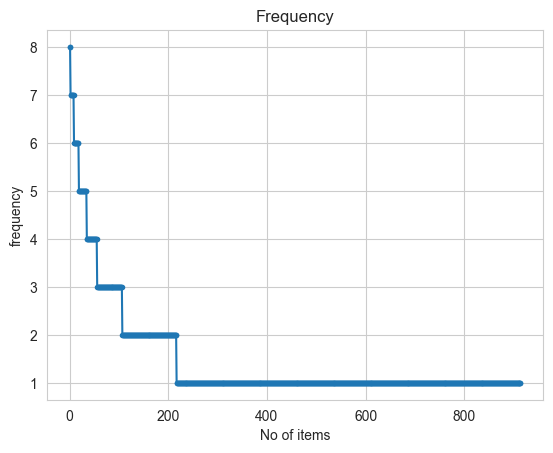

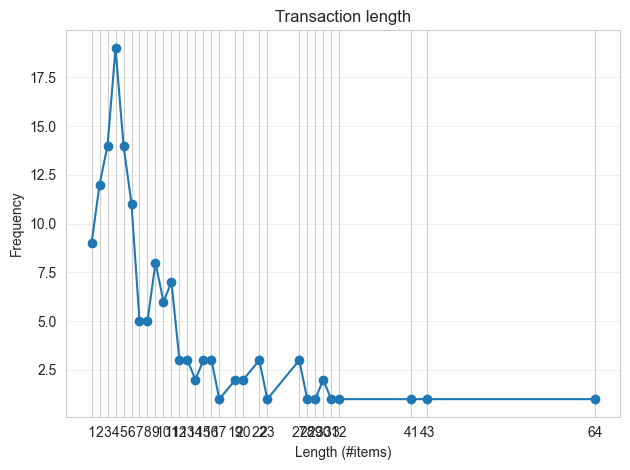

In [43]:
from PAMI.extras.dbStats import TransactionalDatabase as tds
obj = tds.TransactionalDatabase('td_freq_db_wallstreetbets.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

Database size (total no of transactions) : 248
Number of items : 1499
Minimum Transaction Size : 1
Average Transaction Size : 10.149193548387096
Maximum Transaction Size : 145
Standard Deviation Transaction Size : 12.355206529309571
Variance in Transaction Sizes : 153.2691491445736
Sparsity : 0.9932293572058792


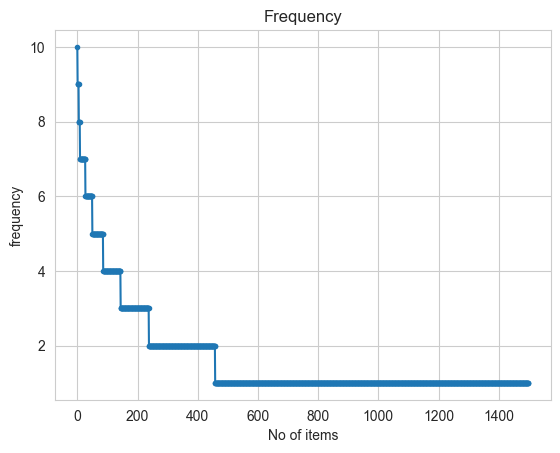

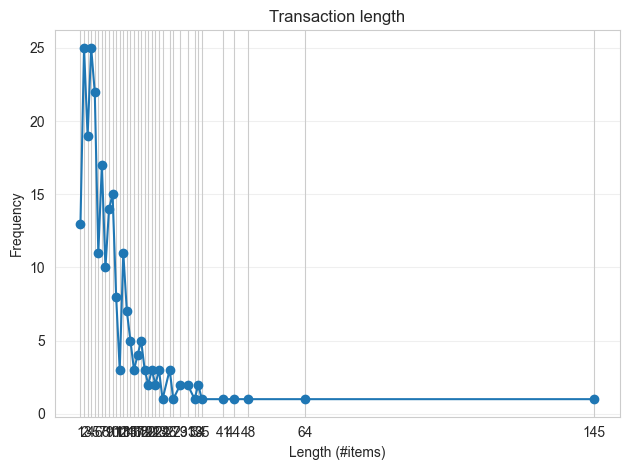

In [44]:
from PAMI.extras.dbStats import TransactionalDatabase as tds
obj = tds.TransactionalDatabase('td_freq_db_StockMarket.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

Database size (total no of transactions) : 171
Number of items : 1522
Minimum Transaction Size : 1
Average Transaction Size : 14.128654970760234
Maximum Transaction Size : 219
Standard Deviation Transaction Size : 25.81118683879441
Variance in Transaction Sizes : 670.1362917096664
Sparsity : 0.9907170466683572


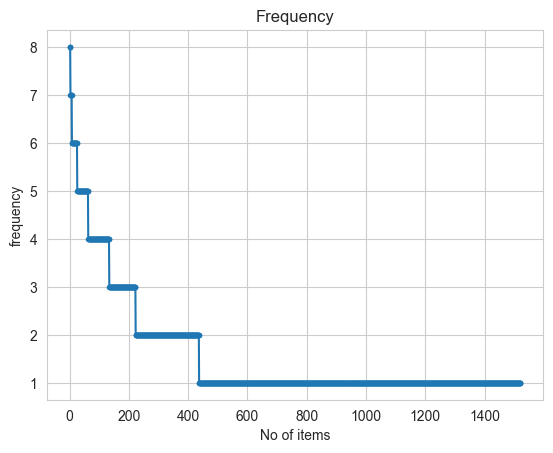

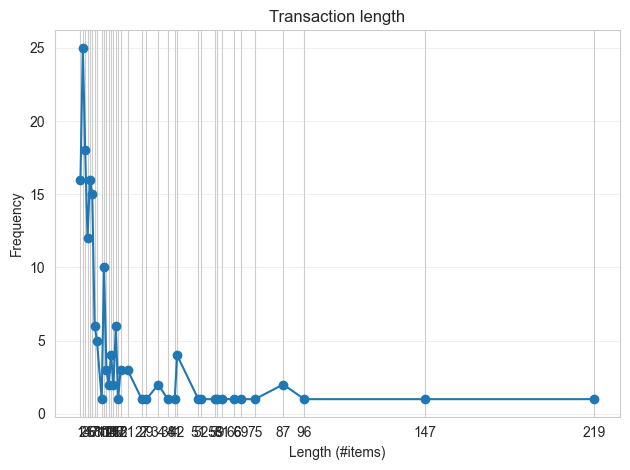

In [45]:
from PAMI.extras.dbStats import TransactionalDatabase as tds
obj = tds.TransactionalDatabase('td_freq_db_stockstobuytoday.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

Database size (total no of transactions) : 274
Number of items : 2206
Minimum Transaction Size : 1
Average Transaction Size : 14.299270072992702
Maximum Transaction Size : 164
Standard Deviation Transaction Size : 16.962330512093942
Variance in Transaction Sizes : 288.7745782198337
Sparsity : 0.9935180099397132


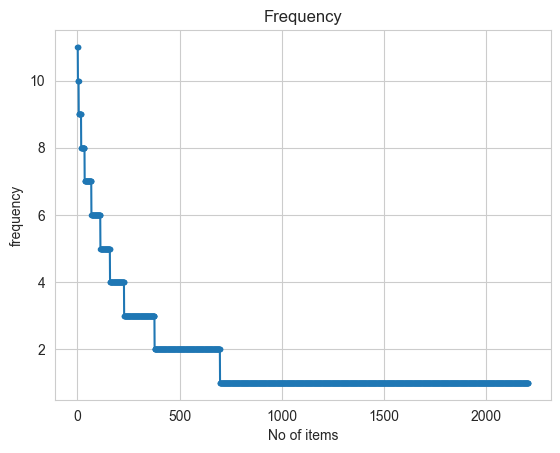

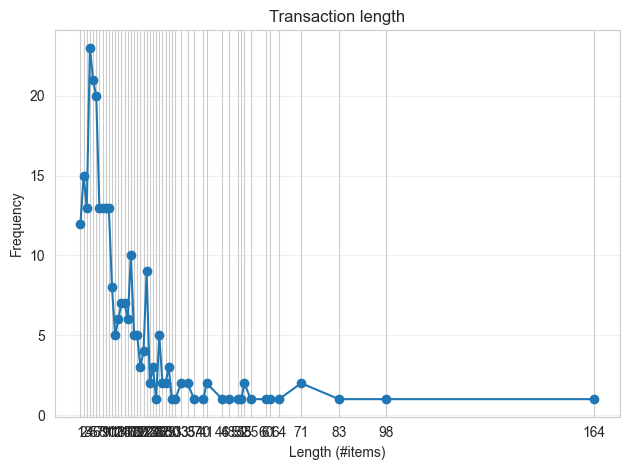

In [46]:
from PAMI.extras.dbStats import TransactionalDatabase as tds
obj = tds.TransactionalDatabase('td_freq_db_stocks.csv')
obj.run()
obj.printStats()
obj.plotGraphs()

### Start using FPGrowth

In [47]:
from PAMI.frequentPattern.basic import FPGrowth as alg
minSup=6
obj1 = alg.FPGrowth(iFile='td_freq_db_wallstreetbets.csv', minSup=minSup)
obj1.mine()
frequentPatternsDF_wallstreetbets= obj1.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF_wallstreetbets))) #print the total number of patterns
print('Runtime: ' + str(obj1.getRuntime())) #measure the runtime

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 19
Runtime: 0.0020008087158203125


In [48]:
obj1.save('freq_patterns_wallstreetbets_minSup9.txt') #save the patterns
frequentPatternsDF_wallstreetbets

,Patterns,Support
0,calls,6
1,did,6
2,been,6
3,by,6
4,then,6
5,retarded,6
6,only,6
7,day,6
8,ve,6
9,get,6


In [49]:
from PAMI.frequentPattern.basic import FPGrowth as alg
minSup=6
obj2 = alg.FPGrowth(iFile='td_freq_db_StockMarket.csv', minSup=minSup)
obj2.mine()
frequentPatternsDF_StockMarket= obj2.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF_StockMarket))) #print the total number of patterns
print('Runtime: ' + str(obj2.getRuntime())) #measure the runtime

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 50
Runtime: 0.0070018768310546875


In [50]:
obj2.save('freq_patterns_StockMarket_minSup9.txt') #save the patterns
frequentPatternsDF_StockMarket

,Patterns,Support
0,trade,6
1,usd,6
2,sure,6
3,did,6
4,since,6
5,some,6
6,gonna,6
7,trading,6
8,plan,6
9,bad,6


In [51]:
from PAMI.frequentPattern.basic import FPGrowth as alg
minSup=6
obj3 = alg.FPGrowth(iFile='td_freq_db_stockstobuytoday.csv', minSup=minSup)
obj3.mine()
frequentPatternsDF_stockstobuytoday= obj3.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF_stockstobuytoday))) #print the total number of patterns
print('Runtime: ' + str(obj3.getRuntime())) #measure the runtime

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 30
Runtime: 0.009999752044677734


In [52]:
obj3.save('freq_patterns_stockstobuytoday_minSup9.txt') #save the patterns
frequentPatternsDF_stockstobuytoday

,Patterns,Support
0,rise,6
1,all,6
2,cap,6
3,do,6
4,many,6
5,right,6
6,we,6
7,shorts,6
8,should,6
9,too,6


In [53]:
from PAMI.frequentPattern.basic import FPGrowth as alg
minSup=6
obj4 = alg.FPGrowth(iFile='td_freq_db_stocks.csv', minSup=minSup)
obj4.mine()
frequentPatternsDF_stocks= obj4.getPatternsAsDataFrame()
print('Total No of patterns: ' + str(len(frequentPatternsDF_stocks))) #print the total number of patterns
print('Runtime: ' + str(obj4.getRuntime())) #measure the runtime

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total No of patterns: 113
Runtime: 0.016995668411254883


In [54]:
obj4.save('freq_patterns_stocks_minSup9.txt') #save the patterns
frequentPatternsDF_stocks

,Patterns,Support
0,few,6
1,lot,6
2,high,6
3,new,6
4,call,6
...,...,...
108,bad,10
109,know,10
110,also,11
111,since,11


In [55]:
import pandas as pd

#We group together all of the dataframes related to our found patterns
dfs = [frequentPatternsDF_wallstreetbets, frequentPatternsDF_StockMarket, 
       frequentPatternsDF_stockstobuytoday, frequentPatternsDF_stocks]


# Identify patterns that appear in more than one category
# Count how many times each pattern appears across all dataframes
pattern_counts = {}
for df in dfs:
    for pattern in df['Patterns']:
        if pattern not in pattern_counts:
            pattern_counts[pattern] = 1
        else:
            pattern_counts[pattern] += 1

# Filter out patterns that appear in more than one dataframe
unique_patterns = {pattern for pattern, count in pattern_counts.items() if count == 1}
# Calculate the total number of patterns across all categories
total_patterns_count = sum(len(df) for df in dfs)
# Calculate how many patterns were discarded
discarded_patterns_count = total_patterns_count - len(unique_patterns)

# For each category, filter the patterns to keep only the unique ones
filtered_dfs = []
for df in dfs:
    filtered_df = df[df['Patterns'].isin(unique_patterns)]
    filtered_dfs.append(filtered_df)

# Merge the filtered dataframes into a final dataframe
final_pattern_df = pd.concat(filtered_dfs, ignore_index=True)

# Sort by support
final_pattern_df = final_pattern_df.sort_values(by='Support', ascending=False)

# Display the final result
print(final_pattern_df)
# Print the number of discarded patterns
print(f"Number of patterns discarded: {discarded_patterns_count}")

     Patterns  Support
145      also       11
37      other       10
144      shit       10
143       him       10
35        why        9
..        ...      ...
91      worse        6
95         50        6
94   treasury        6
84      short        6
85       stop        6

[146 rows x 2 columns]
Number of patterns discarded: 66


In [56]:
import pandas as pd

# Step 1: Reload the original CSV file to reset the 'df' variable
df = pd.read_csv('newdataset/Reddit-stock-sentiment.csv')

# Step 2: Perform the necessary cleaning again
df.dropna(subset=['text'], inplace=True)
df = df[df['text'].apply(isinstance, args=(str,))]

print("DataFrame has been reloaded and cleaned successfully. You can now rerun your code.")

DataFrame has been reloaded and cleaned successfully. You can now rerun your code.


In [57]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

#Convert 'text' column into term-document matrix using CountVectorizer
count_vect = CountVectorizer()
df_tdm = count_vect.fit_transform(df['text']) 
terms = count_vect.get_feature_names_out()  # Original terms in the vocabulary

#Tokenize the sentences into sets of unique words
df['tokenized_text'] = df['text'].str.split().apply(set)

#Initialize the pattern matrix
pattern_matrix = pd.DataFrame(0, index=df.index, columns=final_pattern_df['Patterns'])

#Iterate over each pattern and check if all words in the pattern are present in the tokenized sentence
for pattern in final_pattern_df['Patterns']:
    pattern_words = set(pattern.split())  # Tokenize pattern into words
    pattern_matrix[pattern] = df['tokenized_text'].apply(lambda df: 1 if pattern_words.issubset(df) else 0)

#Convert the term-document matrix to a DataFrame for easy merging
tdm_df = pd.DataFrame(df_tdm.toarray(), columns=terms, index=df.index)

#Concatenate the original TDM and the pattern matrix to augment the features
augmented_df = pd.concat([tdm_df, pattern_matrix], axis=1)
augmented_df

,00,000,01378,02,027,03,06,08,10,100,...,ago,put,won,media,trust,worse,50,treasury,short,stop
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
843,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
844,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
845,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Using FAE like Exercise 17

In [58]:
# Answer Here
from PAMI.frequentPattern.topk import FAE  as alg

inputFile = 'td_freq_db_wallstreetbets.csv'

seperator='\t'
minimumSupportCountList = [50, 100, 150]

result = pd.DataFrame(columns=['algorithm', 'minSup', 'patterns', 'runtime', 'memory'])

algorithm = 'FAE'  #specify the algorithm name
for minSupCount in minimumSupportCountList:
    obj = alg.FAE( iFile=inputFile, k=minSupCount, sep=seperator)
    obj.mine()
    #store the results in the data frame
    result.loc[result.shape[0]] = [algorithm, minSupCount, len(obj.getPatterns()), obj.getRuntime(), obj.getMemoryRSS()]

frequentPatternsDF= obj.getPatternsAsDataFrame()

print(result)

 TopK frequent patterns were successfully generated using FAE algorithm.
 TopK frequent patterns were successfully generated using FAE algorithm.
 TopK frequent patterns were successfully generated using FAE algorithm.
  algorithm  minSup  patterns   runtime     memory
0       FAE      50        50  0.007001  420151296
1       FAE     100       100  0.005001  420151296
2       FAE     150       150  0.017001  420155392


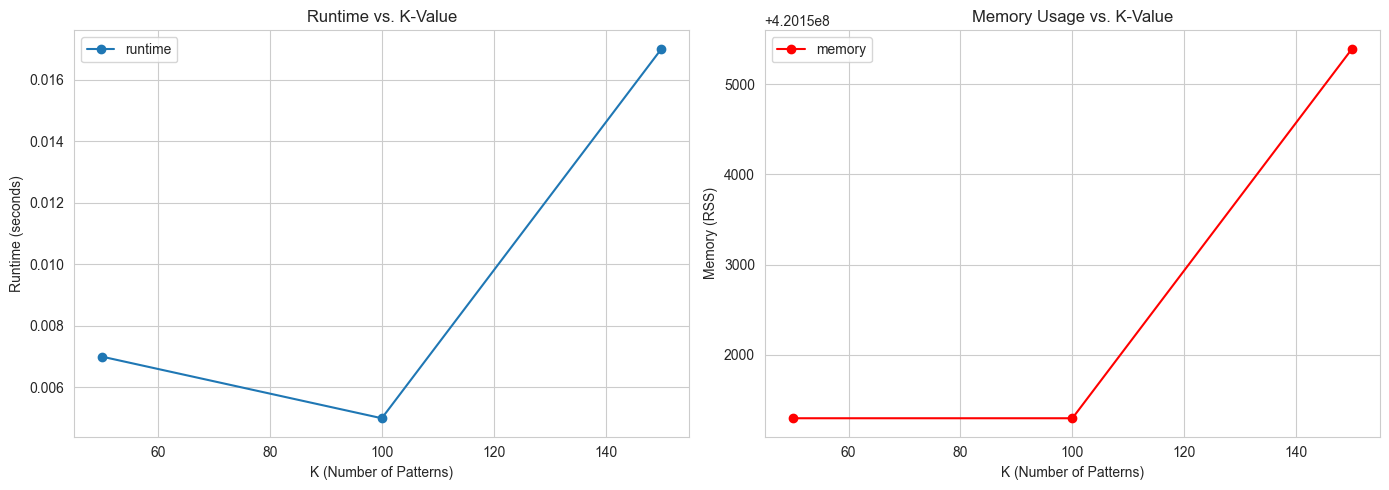

In [59]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Plot Runtime vs. K-Value (minSup)
result.plot(x='minSup', y='runtime', ax=axes[0], marker='o', grid=True)
axes[0].set_title('Runtime vs. K-Value')
axes[0].set_xlabel('K (Number of Patterns)')
axes[0].set_ylabel('Runtime (seconds)')

# Plot Memory vs. K-Value (minSup)
result.plot(x='minSup', y='memory', ax=axes[1], marker='o', color='r', grid=True)
axes[1].set_title('Memory Usage vs. K-Value')
axes[1].set_xlabel('K (Number of Patterns)')
axes[1].set_ylabel('Memory (RSS)')

# Show the plot
plt.tight_layout()
plt.show()

In [60]:
#Import the libraries
from PAMI.frequentPattern.maximal import MaxFPGrowth  as alg #import the algorithm
import pandas as pd

#Specify the input parameters
inputFile = 'td_freq_db_wallstreetbets.csv'
seperator='\t'
minimumSupportCountList = [3, 6, 9]
#minimumSupport can also specified between 0 to 1. E.g., minSupList = [0.005, 0.006, 0.007, 0.008, 0.009]

result = pd.DataFrame(columns=['algorithm', 'minSup', 'patterns', 'runtime', 'memory'])
#initialize a data frame to store the results of MaxFPGrowth algorithm

for minSupCount in minimumSupportCountList:
    obj = alg.MaxFPGrowth(inputFile, minSup=minSupCount, sep=seperator)
    obj.mine()
    #store the results in the data frame
    result.loc[result.shape[0]] = ['MaxFPGrowth', minSupCount, len(obj.getPatterns()), obj.getRuntime(), obj.getMemoryRSS()]
    
print(result)

Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
Maximal Frequent patterns were generated successfully using MaxFp-Growth algorithm 
     algorithm  minSup  patterns   runtime     memory
0  MaxFPGrowth       3       100  0.012993  418086912
1  MaxFPGrowth       6        18  0.002002  418086912
2  MaxFPGrowth       9         0  0.004000  418086912


### Dimensionality Reduction

In [61]:
#Applying dimensionality reduction with only the document-term frequency data
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt

#This might take a couple of minutes to execute
# Apply PCA, t-SNE, and UMAP to the data
X_pca_tdm = PCA(n_components=2).fit_transform(tdm_df.values)
X_tsne_tdm = TSNE(n_components=2).fit_transform(tdm_df.values)
X_umap_tdm = umap.UMAP(n_components=2).fit_transform(tdm_df.values)

In [62]:
X_pca_tdm.shape

(847, 2)

In [63]:
X_tsne_tdm.shape

(847, 2)

In [64]:
X_umap_tdm.shape

(847, 2)

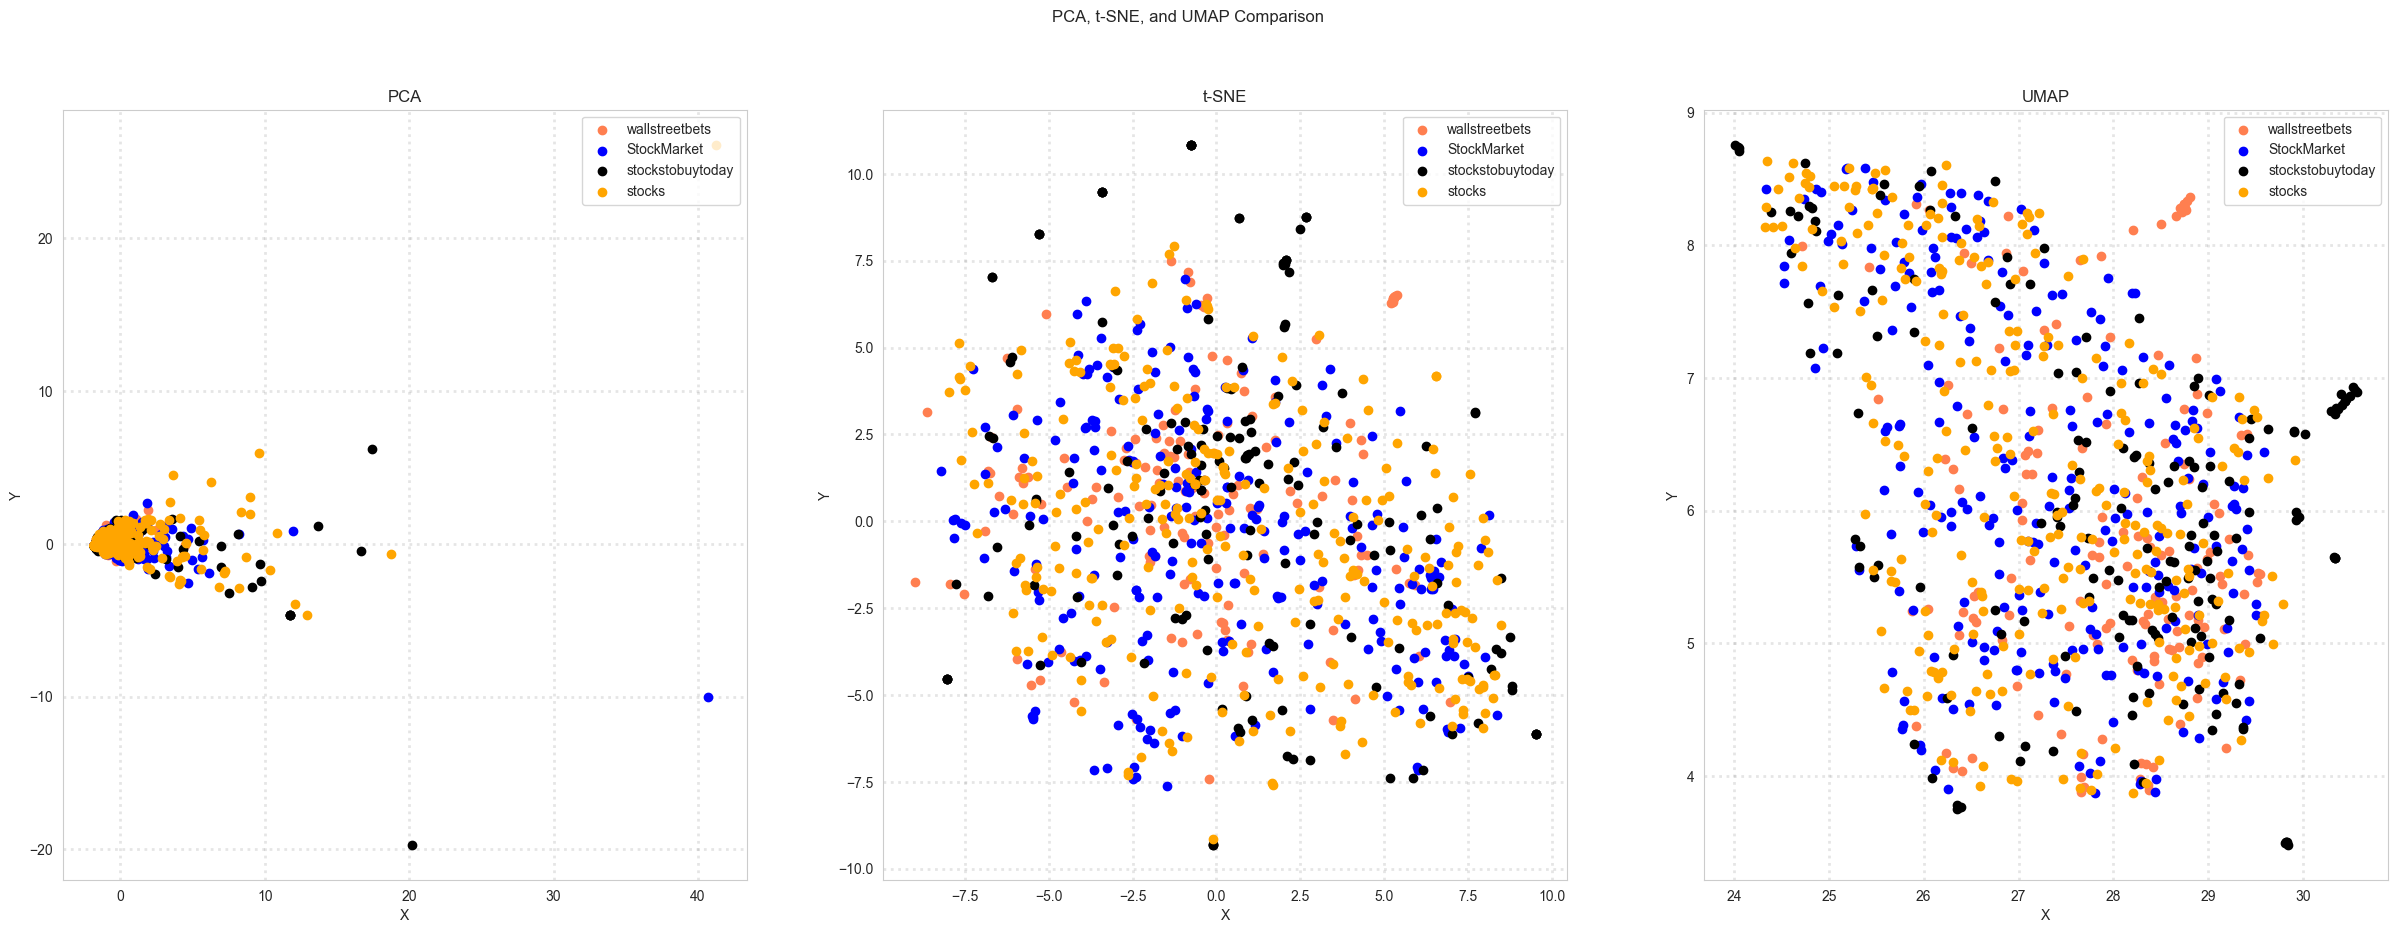

In [65]:
# Plot the results in subplots
col = ['coral', 'blue', 'black', 'orange']
subreddits = df['subreddit'].unique() 

fig, axes = plt.subplots(1, 3, figsize=(30, 10))  # Create 3 subplots for PCA, t-SNE, and UMAP
fig.suptitle('PCA, t-SNE, and UMAP Comparison')

# Define a function to create a scatter plot for each method
def plot_scatter(ax, X_reduced, title):
    for c, category in zip(col, subreddits):
        xs = X_reduced[df['subreddit'] == category].T[0]
        ys = X_reduced[df['subreddit'] == category].T[1]
        ax.scatter(xs, ys, c=c, marker='o', label=category)
    
    ax.grid(color='gray', linestyle=':', linewidth=2, alpha=0.2)
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(loc='upper right')

# Step 4: Create scatter plots for PCA, t-SNE, and UMAP
plot_scatter(axes[0], X_pca_tdm, 'PCA')
plot_scatter(axes[1], X_tsne_tdm, 't-SNE')
plot_scatter(axes[2], X_umap_tdm, 'UMAP')

plt.show()

In [66]:
#This might take a couple of minutes to execute
#Applying dimensionality reduction with both the document-term frequency data and the pattern derived data
# Apply PCA, t-SNE, and UMAP to the data
X_pca_aug = PCA(n_components=2).fit_transform(augmented_df.values)
X_tsne_aug = TSNE(n_components=2).fit_transform(augmented_df.values)
X_umap_aug = umap.UMAP(n_components=2).fit_transform(augmented_df.values)

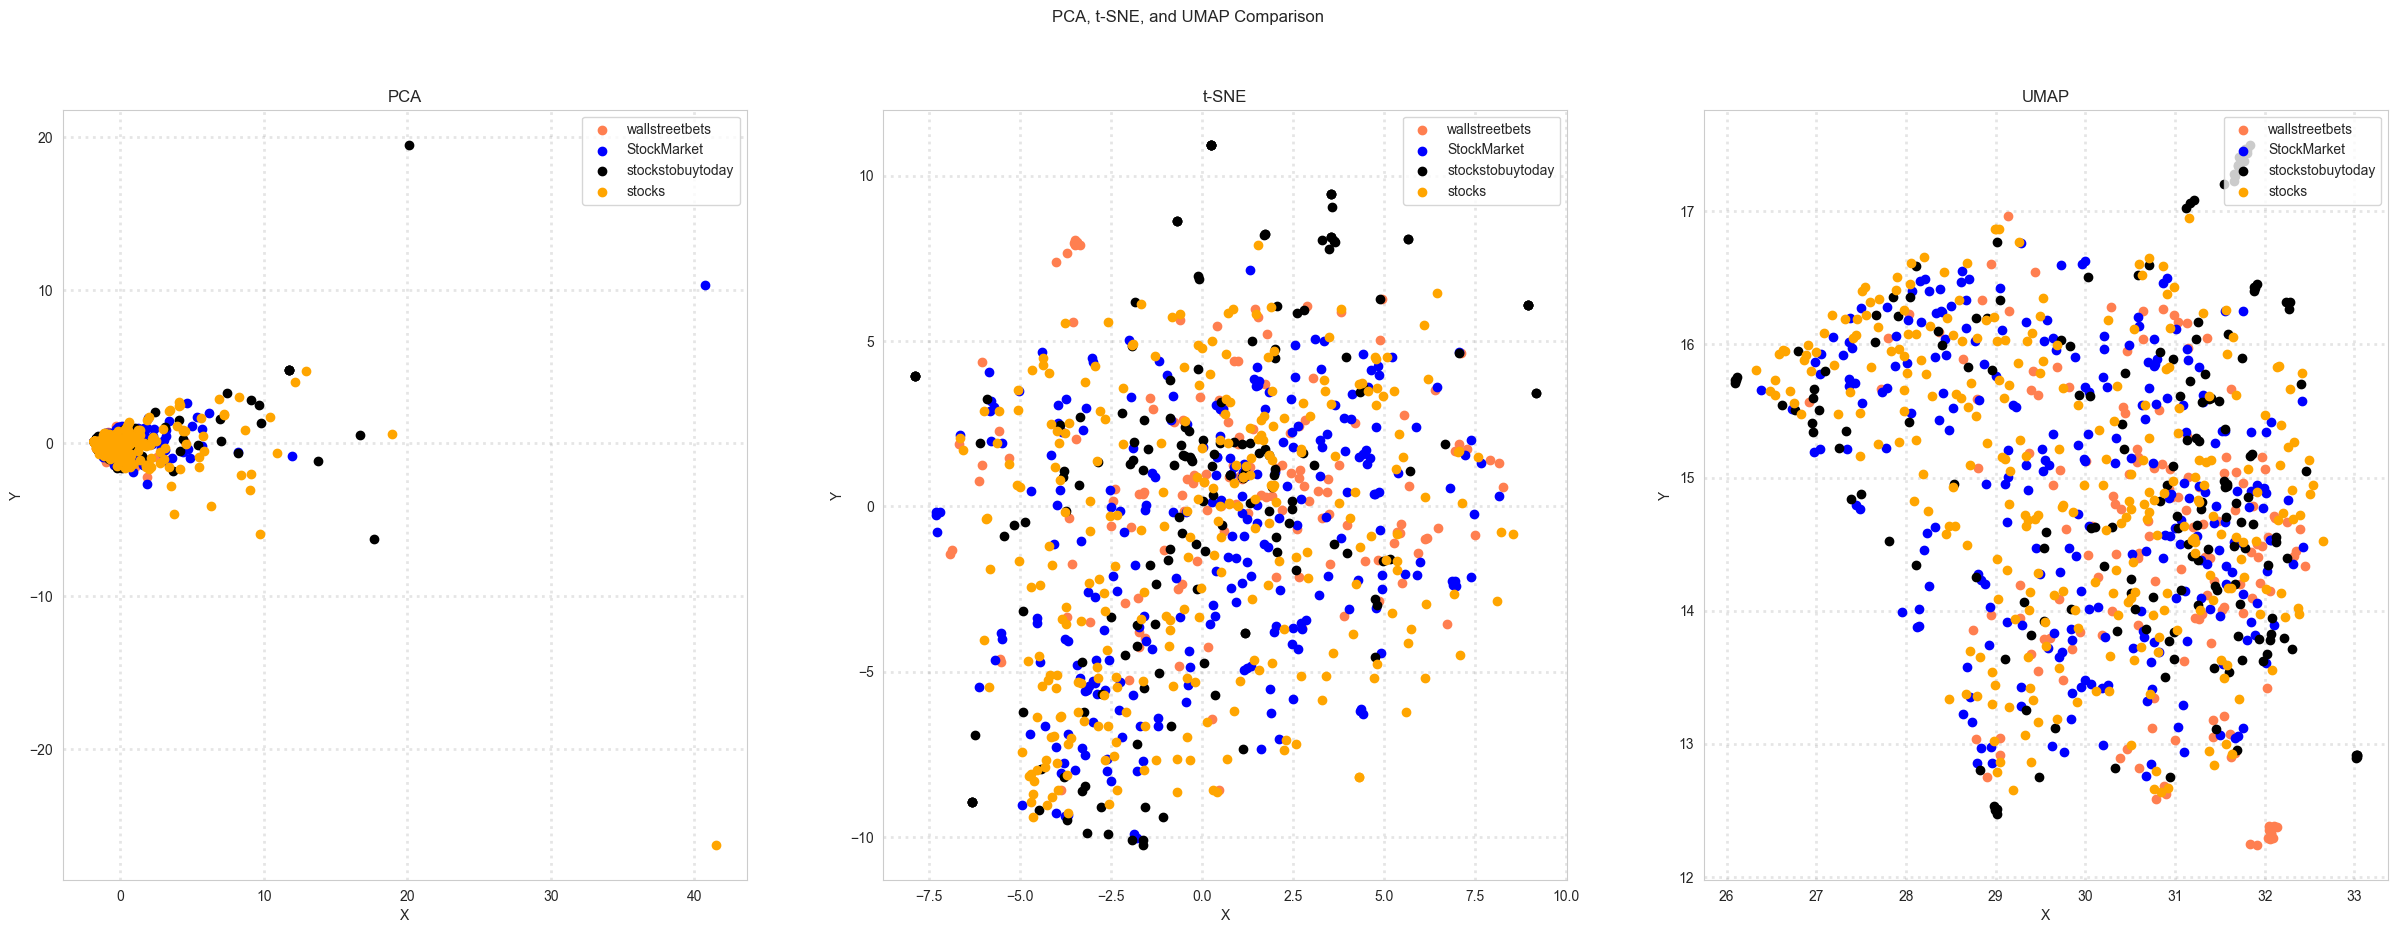

In [67]:
# Plot the results in subplots
col = ['coral', 'blue', 'black', 'orange']
subreddits = df['subreddit'].unique() 

fig, axes = plt.subplots(1, 3, figsize=(30, 10))  # Create 3 subplots for PCA, t-SNE, and UMAP
fig.suptitle('PCA, t-SNE, and UMAP Comparison')

# Define a function to create a scatter plot for each method
def plot_scatter(ax, X_reduced, title):
    for c, category in zip(col, subreddits):
        xs = X_reduced[df['subreddit'] == category].T[0]
        ys = X_reduced[df['subreddit'] == category].T[1]
        ax.scatter(xs, ys, c=c, marker='o', label=category)
    
    ax.grid(color='gray', linestyle=':', linewidth=2, alpha=0.2)
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(loc='upper right')

# Step 4: Create scatter plots for PCA, t-SNE, and UMAP
plot_scatter(axes[0], X_pca_aug, 'PCA')
plot_scatter(axes[1], X_tsne_aug, 't-SNE')
plot_scatter(axes[2], X_umap_aug, 'UMAP')

plt.show()

### 3D Plot like exercise 18

In [68]:
#Answer Here
#This might take a couple of minutes to execute
#Applying dimensionality reduction with both the document-term frequency data and the pattern derived data
# Apply PCA, t-SNE, and UMAP to the data
X_pca_3d = PCA(n_components=3).fit_transform(augmented_df.values)
X_tsne_3d = TSNE(n_components=3).fit_transform(augmented_df.values)
X_umap_3d = umap.UMAP(n_components=3).fit_transform(augmented_df.values)

Running dimensionality reduction to 3 components...
Dimensionality reduction complete.


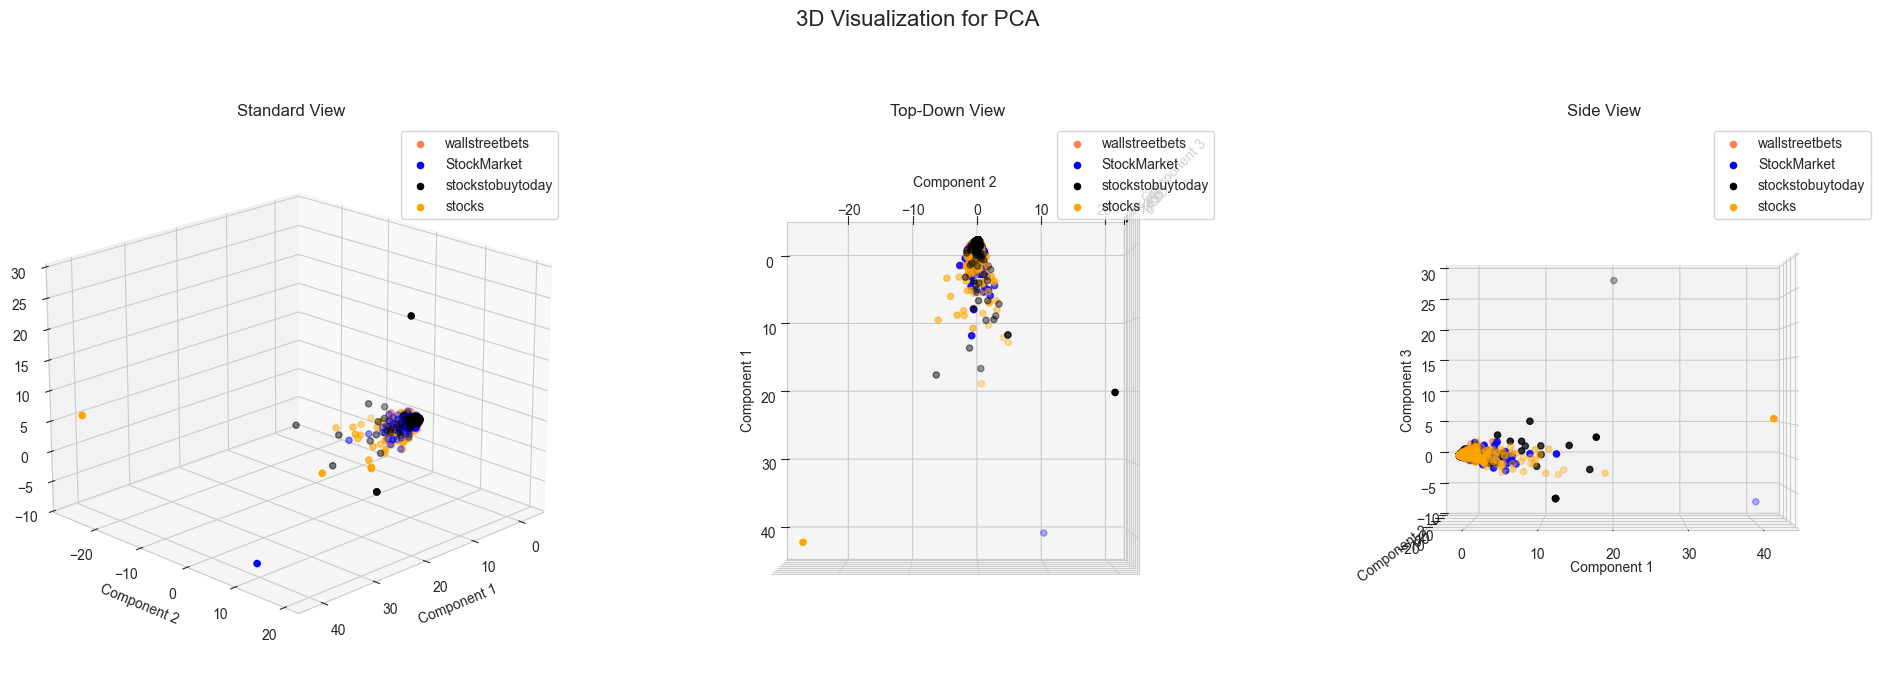

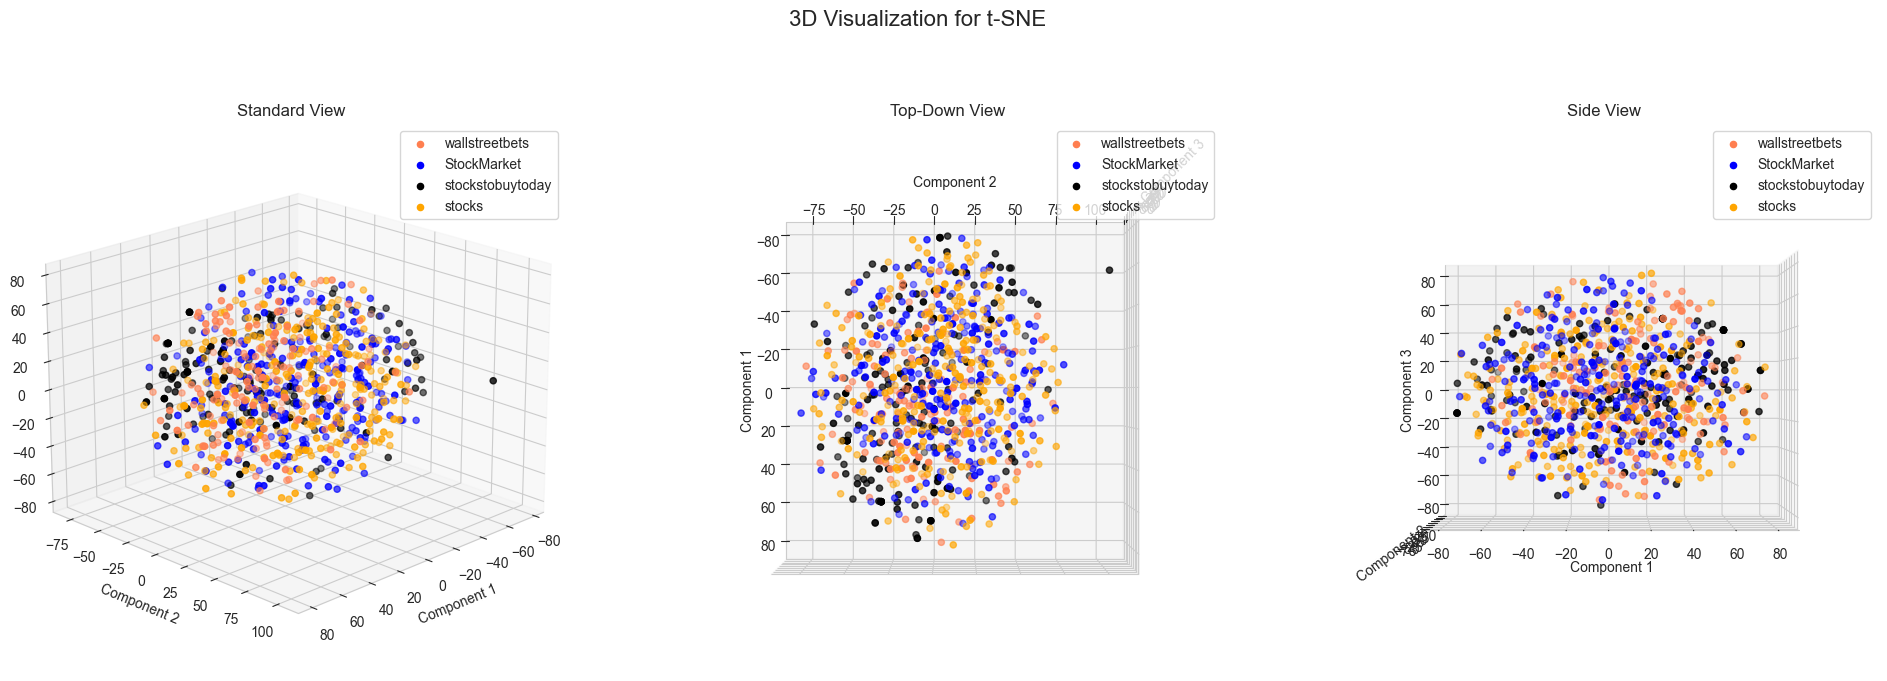

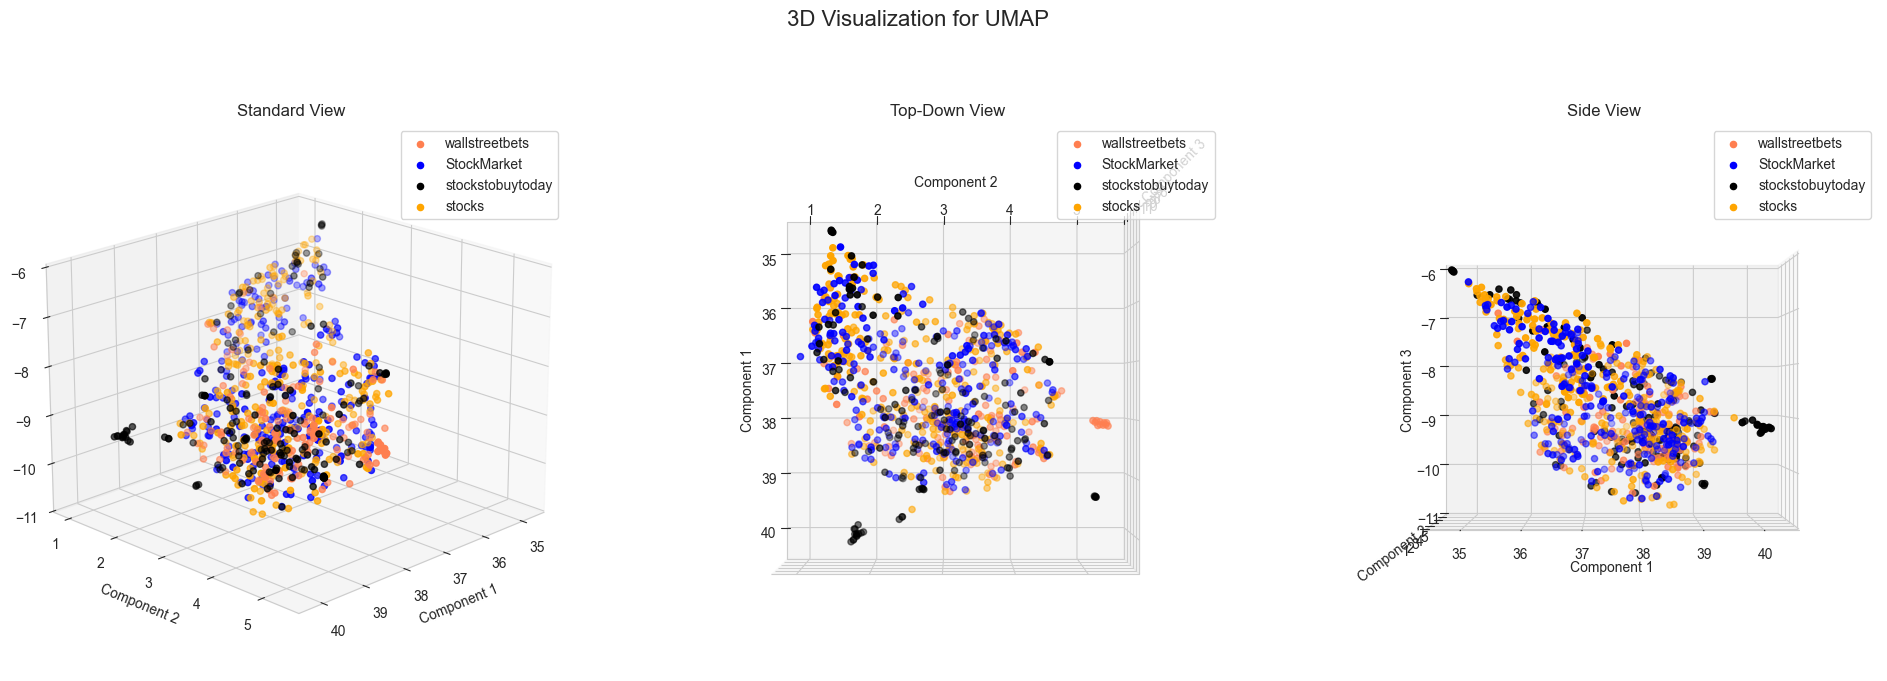

In [69]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# --- 1. Perform Dimensionality Reduction to 3D (This part is correct) ---
print("Running dimensionality reduction to 3 components...")
# This might take a couple of minutes
X_pca_3d = PCA(n_components=3).fit_transform(augmented_df.values)
X_tsne_3d = TSNE(n_components=3).fit_transform(augmented_df.values)
X_umap_3d = umap.UMAP(n_components=3).fit_transform(augmented_df.values)
print("Dimensionality reduction complete.")

# --- 2. Define Plotting Variables and Function ---
col = ['coral', 'blue', 'black', 'orange']
subreddits = df['subreddit'].unique()

def plot_3d_from_angles(X_reduced, algorithm_name):
    """A function to plot a 3D scatter plot from three different angles."""
    fig = plt.figure(figsize=(24, 8))
    fig.suptitle(f'3D Visualization for {algorithm_name}', fontsize=16)

    angles = {
        "Standard View": (20, 45),
        "Top-Down View": (90, 0),
        "Side View": (0, -90)
    }

    for i, (view_name, angle) in enumerate(angles.items()):
        ax = fig.add_subplot(1, 3, i + 1, projection='3d')
        for c, category in zip(col, subreddits):
            xs = X_reduced[df['subreddit'] == category, 0]
            ys = X_reduced[df['subreddit'] == category, 1]
            zs = X_reduced[df['subreddit'] == category, 2]
            ax.scatter(xs, ys, zs, c=c, marker='o', label=category)
        
        ax.set_title(view_name)
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
        ax.set_zlabel('Component 3')
        ax.legend(loc='upper right')
        ax.view_init(elev=angle[0], azim=angle[1])
    
    plt.show()

# --- 3. Generate a 3D Plot for Each Algorithm ---
plot_3d_from_angles(X_pca_3d, "PCA")
plot_3d_from_angles(X_tsne_3d, "t-SNE")
plot_3d_from_angles(X_umap_3d, "UMAP")

### Discretization and Binarization like exercise 19

In [70]:
from sklearn import preprocessing, metrics, decomposition, pipeline, dummy
mlb = preprocessing.LabelBinarizer()
mlb.fit(df.subreddit)

LabelBinarizer()

In [71]:
df['bin_subreddit'] = mlb.transform(df['subreddit']).tolist()
df[0:9]

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label,tokenized_text,bin_subreddit
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0,"{retards, Calls, on}","[0, 0, 0, 1]"
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0,"{about, place?, first, No, a, big, they, even,...","[0, 0, 0, 1]"
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0,"{of, in, ticker., red, Seeing, lots, the}","[1, 0, 0, 0]"
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0,"{feat, This, of, just, achieved, Torrente, hav...","[0, 0, 1, 0]"
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didnât say thank you.,0.000000,0.000000,0.0,[],-1.0,"{you., say, He, didnât, thank}","[1, 0, 0, 0]"
5,comment,2025-04-12 2:19:03,mmo4k9g,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,PolarNimbus,https://www.reddit.com/r/wallstreetbets/commen...,16,NaN,NaN,"Hoping to ejaculate in wet warm puss tonight, ...",0.500000,0.250000,1.0,"['tonight', 'puss']",0.0,"{tonight,, puss, warm, ejaculate, wet, to, wis...","[0, 0, 0, 1]"
6,comment,2025-04-11 12:37:23,mmjx7vz,stocks,Is the market in complete denial right now?,stoniey84,https://www.reddit.com/r/stocks/comments/1jwo1...,5,NaN,NaN,Trump will respond to china increasing their t...,0.380000,-0.108333,-1.0,"['JPow', 'Jerome', 'i', 'reporting', 'Trump', ...",-1.0,"{down, increasing, see, JPow, it, going, bruta...","[0, 1, 0, 0]"
7,comment,2025-04-11 17:28:50,mmlhxwc,wallstreetbets,Retardation is on the menu boys! WSB is so back,OSRSkarma,https://i.redd.it/0yq2ftren8ue1.jpeg,-3,NaN,NaN,Confirmed not a trap. Its been like this for p...,0.700000,0.050000,1.0,"['Confirmed', 'mouth', 'word', 'trap']",0.0,"{by, of, Confirmed, just, trap., word, have, I...","[0, 0, 0, 1]"
8,comment,2021-02-01 15:36:32,gllyi5z,stocks,"It's fucking awful seeing the ""Silver"" misinfo...",Blondbox,https://www.reddit.com/r/stocks/comments/la34b...,1,NaN,NaN,Am I the only one seeing the cup & handle brea...,0.491818,0.057045,1.0,"['cup', 'Day', 'handle', 'pivot', 'Green', 'tr...",1.0,"{was, week, technicals, The, only, base, to, P...","[0, 1, 0, 0]"


###  Data Exploration like exercise 20

In [72]:
# We retrieve 3 sentences for a random record
document_to_transform_1 = []
random_record_1 = df.iloc[10]
random_record_1 = random_record_1['text']
document_to_transform_1.append(random_record_1)

document_to_transform_2 = []
random_record_2 = df.iloc[50]
random_record_2 = random_record_2['text']
document_to_transform_2.append(random_record_2)

document_to_transform_3 = []
random_record_3 = df.iloc[100]
random_record_3 = random_record_3['text']
document_to_transform_3.append(random_record_3)

In [73]:
print(document_to_transform_1)
print()
print(document_to_transform_2)
print()
print(document_to_transform_3)

["It's a copy/paste from a Bloomberg terminal."]

['Yup - money, money']

['Do we have a copy of trumpâ\x80\x99s kindergarten graduation certificate? Ideally the long form version.']


In [74]:
from sklearn.preprocessing import binarize

# Transform sentence with Vectorizers
document_vector_count_1 = count_vect.transform(document_to_transform_1)
document_vector_count_2 = count_vect.transform(document_to_transform_2)
document_vector_count_3 = count_vect.transform(document_to_transform_3)

# Binarize vectors to simplify: 0 for abscence, 1 for prescence
document_vector_count_1_bin = binarize(document_vector_count_1)
document_vector_count_2_bin = binarize(document_vector_count_2)
document_vector_count_3_bin = binarize(document_vector_count_3)

# print vectors
print("Let's take a look at the count vectors:")
print(document_vector_count_1.todense())
print(document_vector_count_2.todense())
print(document_vector_count_3.todense())

Let's take a look at the count vectors:
[[0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]]


In [75]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate Cosine Similarity
cos_sim_count_1_2 = cosine_similarity(document_vector_count_1, document_vector_count_2, dense_output=True)
cos_sim_count_1_3 = cosine_similarity(document_vector_count_1, document_vector_count_3, dense_output=True)
cos_sim_count_2_3 = cosine_similarity(document_vector_count_2, document_vector_count_3, dense_output=True)

cos_sim_count_1_1 = cosine_similarity(document_vector_count_1, document_vector_count_1, dense_output=True)
cos_sim_count_2_2 = cosine_similarity(document_vector_count_2, document_vector_count_2, dense_output=True)
cos_sim_count_3_3 = cosine_similarity(document_vector_count_3, document_vector_count_3, dense_output=True)

# Print 
print("Cosine Similarity using count bw 1 and 2: %(x)f" %{"x":cos_sim_count_1_2})
print("Cosine Similarity using count bw 1 and 3: %(x)f" %{"x":cos_sim_count_1_3})
print("Cosine Similarity using count bw 2 and 3: %(x)f" %{"x":cos_sim_count_2_3})
    
print("Cosine Similarity using count bw 1 and 1: %(x)f" %{"x":cos_sim_count_1_1})
print("Cosine Similarity using count bw 2 and 2: %(x)f" %{"x":cos_sim_count_2_2})
print("Cosine Similarity using count bw 3 and 3: %(x)f" %{"x":cos_sim_count_3_3})

Cosine Similarity using count bw 1 and 2: 0.000000
Cosine Similarity using count bw 1 and 3: 0.109109
Cosine Similarity using count bw 2 and 3: 0.000000
Cosine Similarity using count bw 1 and 1: 1.000000
Cosine Similarity using count bw 2 and 2: 1.000000
Cosine Similarity using count bw 3 and 3: 1.000000


C:\Users\ASUS\AppData\Local\Temp\ipykernel_4436\4126710102.py:13: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4436\4126710102.py:14: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4436\4126710102.py:15: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4436\4126710102.py:17: DeprecationWarning:

Conversion of an array with ndim > 0 to a scal

### Data Classification
### Use the TDM to perform classification using Naive Bayes

In [76]:
#Model with only the document-term frequency data
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Get the target labels (the subreddit names) from your main DataFrame
labels = df['subreddit']

# Get the names of the categories for the classification report
target_names = sorted(labels.unique())

# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(tdm_df, df['subreddit'], test_size=0.3, random_state=42)

In [77]:
X_train

,00,000,01378,02,027,03,06,08,10,100,...,yourself,yourselves,youtube,youâ,yoyo,yup,zero,zgld,zone,zsil
739,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
140,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
173,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
552,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
106,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
270,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
435,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [78]:
X_test

,00,000,01378,02,027,03,06,08,10,100,...,yourself,yourselves,youtube,youâ,yoyo,yup,zero,zgld,zone,zsil
457,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
342,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
280,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
275,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
843,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
766,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
548,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
351,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
136,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [79]:
# Train the Naive Bayes classifier
nb_classifier = MultinomialNB() #create new student
nb_classifier.fit(X_train, y_train) #study session

# Make predictions on the test set 
y_pred = nb_classifier.predict(X_test) #give the test

# Evaluate the classifier
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names, digits=4))

Accuracy: 0.5450980392156862

Classification Report:
                   precision    recall  f1-score   support

     StockMarket     0.5357    0.6250    0.5769        72
          stocks     0.4803    0.7011    0.5701        87
stockstobuytoday     0.7826    0.3673    0.5000        49
  wallstreetbets     0.7143    0.3191    0.4412        47

        accuracy                         0.5451       255
       macro avg     0.6282    0.5032    0.5220       255
    weighted avg     0.5972    0.5451    0.5348       255



### Use the augmented to perform classification using Naive Bayes like exercise 21

In [80]:
#Model with only the document-term frequency data
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Get the target labels (the subreddit names) from your main DataFrame
labels = df['subreddit']

# Get the names of the categories for the classification report
target_names = sorted(labels.unique())

# Split the data into training and testing sets (70% train, 30% test)
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(augmented_df, df['subreddit'], test_size=0.3, random_state=42)

In [81]:
# Train the Naive Bayes classifier
nb_classifier = MultinomialNB() #create new student
nb_classifier.fit(X_train_aug, y_train_aug) #study session

# Make predictions on the test set 
y_pred_aug = nb_classifier.predict(X_test_aug) #give the test

# Evaluate the classifier
print("Accuracy:", accuracy_score(y_test_aug, y_pred_aug))
print("\nClassification Report:\n", classification_report(y_test_aug, y_pred_aug, target_names=target_names, digits=4))

Accuracy: 0.5411764705882353

Classification Report:
                   precision    recall  f1-score   support

     StockMarket     0.5422    0.6250    0.5806        72
          stocks     0.4800    0.6897    0.5660        87
stockstobuytoday     0.7500    0.3673    0.4932        49
  wallstreetbets     0.6522    0.3191    0.4286        47

        accuracy                         0.5412       255
       macro avg     0.6061    0.5003    0.5171       255
    weighted avg     0.5812    0.5412    0.5308       255



### Decision Tree Classifier

In [82]:
# Decision Tree with only the document-term frequency data
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Split the data (already done above, but shown here for clarity)
X_train, X_test, y_train, y_test = train_test_split(tdm_df, df['subreddit'], test_size=0.3, random_state=42)

# Train Decision Tree
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt_classifier.predict(X_test)
print("Decision Tree Accuracy (TDM):", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, target_names=target_names, digits=4))

Decision Tree Accuracy (TDM): 0.396078431372549

Classification Report:
                   precision    recall  f1-score   support

     StockMarket     0.3580    0.4028    0.3791        72
          stocks     0.4915    0.3333    0.3973        87
stockstobuytoday     0.4889    0.4490    0.4681        49
  wallstreetbets     0.3000    0.4468    0.3590        47

        accuracy                         0.3961       255
       macro avg     0.4096    0.4080    0.4009       255
    weighted avg     0.4180    0.3961    0.3987       255



In [83]:
#Answer
# Decision Tree with only the document-term frequency data
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Split the data (already done above, but shown here for clarity)
X_train, X_test, y_train, y_test = train_test_split(augmented_df, df['subreddit'], test_size=0.3, random_state=42)

# Train Decision Tree
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt_classifier.predict(X_test)
print("Decision Tree Accuracy (Augmented):", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, target_names=target_names, digits=4))

Decision Tree Accuracy (Augmented): 0.3803921568627451

Classification Report:
                   precision    recall  f1-score   support

     StockMarket     0.3500    0.3889    0.3684        72
          stocks     0.4444    0.3218    0.3733        87
stockstobuytoday     0.4375    0.4286    0.4330        49
  wallstreetbets     0.3125    0.4255    0.3604        47

        accuracy                         0.3804       255
       macro avg     0.3861    0.3912    0.3838       255
    weighted avg     0.3921    0.3804    0.3810       255



### TF-IDF

In [84]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize the TfidfVectorizer
tfidf_vect = TfidfVectorizer()

# 2. Fit the vectorizer to the text data and transform it into a TF-IDF matrix
X_tfidf = tfidf_vect.fit_transform(df['text'])

# 3. Create a new DataFrame from the TF-IDF matrix for inspection
# This makes the output easy to read, with words as columns and documents as rows.
tfidf_df = pd.DataFrame(X_tfidf.toarray(), 
                        columns=tfidf_vect.get_feature_names_out(), 
                        index=df.index)

# Display the head of the new TF-IDF DataFrame
print("--- TF-IDF Feature Matrix ---")
display(tfidf_df)

--- TF-IDF Feature Matrix ---


,00,000,01378,02,027,03,06,08,10,100,...,yourself,yourselves,youtube,youâ,yoyo,yup,zero,zgld,zone,zsil
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
844,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
845,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Classifier 1: Using Word Frequency Features (tdm_df)

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report


# Features are the word counts, and labels are the subreddit names
X_counts = tdm_df
y = df['subreddit']

# Split the data into training and testing sets
X_train_counts, X_test_counts, y_train, y_test = train_test_split(X_counts, y, test_size=0.3, random_state=42)

# Train the Multinomial Naive Bayes classifier
model_counts = MultinomialNB()
model_counts.fit(X_train_counts, y_train)

# Evaluate the model and print the results
predictions_counts = model_counts.predict(X_test_counts)
print("Accuracy:", accuracy_score(y_test, predictions_counts))
print("--- Classification Report (Word Frequency Features) ---")
print(classification_report(y_test, predictions_counts))

Accuracy: 0.5450980392156862
--- Classification Report (Word Frequency Features) ---
                  precision    recall  f1-score   support

     StockMarket       0.54      0.62      0.58        72
          stocks       0.48      0.70      0.57        87
stockstobuytoday       0.78      0.37      0.50        49
  wallstreetbets       0.71      0.32      0.44        47

        accuracy                           0.55       255
       macro avg       0.63      0.50      0.52       255
    weighted avg       0.60      0.55      0.53       255



#### Classifier 2: Using TF-IDF Features (tfidf_df)

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# The features (X) are your TF-IDF word scores
X = tfidf_df
# The labels (y) are the subreddit names from your original DataFrame
y = df['subreddit']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train a Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train, y_train)

# Make predictions and print a report showing the model's performance
predictions = model.predict(X_test)
print("--- Classification Report ---")
print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

--- Classification Report ---
Accuracy: 0.4980392156862745
                  precision    recall  f1-score   support

     StockMarket       0.57      0.60      0.58        72
          stocks       0.42      0.79      0.55        87
stockstobuytoday       1.00      0.24      0.39        49
  wallstreetbets       1.00      0.06      0.12        47

        accuracy                           0.50       255
       macro avg       0.75      0.42      0.41       255
    weighted avg       0.68      0.50      0.45       255



In [87]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# This assumes 'augmented_df' is your DataFrame with both word counts and pattern features,
# and 'df' is your main DataFrame with the labels.

# The features (X) are your combined word counts and frequent patterns.
X_augmented = augmented_df
# The labels (y) are the subreddit names.
y = df['subreddit']

# Split the data into training and testing sets
X_train_aug, X_test_aug, y_train, y_test = train_test_split(X_augmented, y, test_size=0.3, random_state=42)

# Train the Multinomial Naive Bayes classifier on the augmented features
model_augmented = MultinomialNB()
model_augmented.fit(X_train_aug, y_train)

# Evaluate the model and print the results
predictions_augmented = model_augmented.predict(X_test_aug)
print("Accuracy:", accuracy_score(y_test, predictions_augmented))
print("--- Classification Report (Augmented Features) ---")
print(classification_report(y_test, predictions_augmented))

Accuracy: 0.5411764705882353
--- Classification Report (Augmented Features) ---
                  precision    recall  f1-score   support

     StockMarket       0.54      0.62      0.58        72
          stocks       0.48      0.69      0.57        87
stockstobuytoday       0.75      0.37      0.49        49
  wallstreetbets       0.65      0.32      0.43        47

        accuracy                           0.54       255
       macro avg       0.61      0.50      0.52       255
    weighted avg       0.58      0.54      0.53       255



Model Performance Comparison

1. Word Frequency Model 
Accuracy: 54.5%

Analysis: This baseline model achieved the highest accuracy. It provided the best overall balance, successfully identifying the two larger subreddits (StockMarket and stocks) a majority of the time. However, its low recall for stockstobuytoday (37%) and wallstreetbets (32%) shows it still struggled to correctly classify many posts from the smaller communities.

2. TF-IDF Model 
Accuracy: 49.8%

Analysis: This model performed the worst. The drop in accuracy is explained by the catastrophic recall for wallstreetbets (6%) and stockstobuytoday (24%). While the precision for these classes is perfect (1.00), this is misleading. It means the model became extremely conservative and learned to almost never predict these smaller classes to avoid being wrong. In this case, TF-IDF likely over-penalized important keywords that were unique to the smaller subreddits, causing the model to effectively ignore them.

3. Augmented Model 
Accuracy: 54.1%

Analysis: Adding frequent patterns as features did not provide a meaningful boost. The performance is nearly identical to the simple Word Frequency model. This suggests that the extra context from multi-word phrases, while logically useful, wasn't enough for the Naive Bayes classifier to overcome the challenges in the data. The single-word features were already capturing most of the information the model could use.

#### Inefficient Parts I Noticed
1. Basic Tokenization: We used a simple .str.split(). This is inefficient because it doesn't handle punctuation or case. For example, it would treat 'stock.' and 'stock' as two different words, and 'Stock' and 'stock' as two different words, which splits the predictive power of a single concept.


2. Although we filtered out the top 5% and bottom 1% of words after vectorization, this was an inefficient, "brute-force" fix. A proper process involves smarter, targeted cleaning before feature generation. By creating features first, our initial matrix was bloated with noise that hindered the model's performance, including:
- Stop words (like "the", "is") that add no meaningful information.
- Rare words (appearing only once), which are often typos.
- Numbers and symbols (like stock tickers) that have little predictive value.

3. No Word Normalization: We treated different forms of the same word as separate items. For example, "invest," "investing," and "investment" were considered three distinct features. This dilutes their combined importance.

#### How to Improve preprocessing
1. Advanced Text Cleaning
Removes irrelevant noise, like URLs,  punctuation, and numbers—before any processing. This leaves only meaningful text, preventing the model from learning useless patterns.


2. Improved Tokenization & Stop Word Removal
Uses a robust tokenizer that correctly splits words (handling hyphens, contractions, etc.), followed by removing common stop words (e.g., “the,” “is”) that add grammatical structure but no topical meaning.


3. Lemmatization (Word Normalization)
Converts word variants (e.g., 'investing', 'invested', 'investment') to their base form (*invest*), reducing redundancy and helping the model recognize related terms as a single concept.